# **Proyecto Integrador - Predicción de Potenciales Clientes de Internet Hogar**

Integrantes:
- Garcia Berrocal, Bryan Alexander
- Quispe Zevallos, Anthony David
- Zavaleta Zavaleta, Angela
- Castro, Eduardo



### **Caso de uso:** Identificación y segmentación de una base de clientes de un servicio existente para la adquisición de un nuevo producto, detallando la problemática de la falta de procesos estructurados actuales.

### **Objetivo final:** Desarrollar un modelo de aprendizaje automático (clasificación) para predecir la probabilidad de aceptación de una oferta específica basándose en el comportamiento del usuario.

### **Nivel:** Este proyecto es de nivel intermedio a avanzado en Machine Learning y su aplicación profesional se centra en la estrategia comercial, marketing dirigido y retención de clientes.

##**COMPRENSIÓN DEL NEGOCIO**


#### **Objetivo del proyecto**

  * Parámetros de antigüedad y ubicación geográfica.
  * Criterios de exclusión (bajas previas o reclamos activos).
  * Evaluación de salud financiera (comportamiento de pago y deudas).
  * Umbrales de consumo monetario por tipo de contrato.
  * Preferencias de contactabilidad y canales digitales activos.

#### **¿Por qué es útil?**
* Optimiza el gasto de marketing y ventas al dirigir esfuerzos únicamente a leads con alta probabilidad de conversión en lugar de ataques masivos aleatorios.
* Maximiza la penetración del servicio Internet Hogar aprovechando la base instalada de clientes móviles mediante segmentación precisa y personalizada.
* Reduce el riesgo comercial y operativo al filtrar clientes con historial de deudas, reclamos activos o bajas previas del servicio.

### 1. Importación de librerías

In [ ]:
# Dataframe
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Drive
from google.colab import drive
from google.colab import files

## 2. Carga de datos y exploración inicial

### 2.1 Diccionario

**Dataset: `dataset_unificado_ml.csv`**

| # | Variable | Significado |
|---| :--- | :--- |
| 1 | **id_cliente** | Identificador único de cada cliente móvil. |
| 2 | **tipo_linea** | Tipo de línea móvil contratada por el cliente (PREPAGO o POSPAGO). |
| 3 | **fecha_alta_movil** | Fecha en la que el cliente dio de alta el servicio móvil. |
| 4 | **antiguedad_meses** | Número de meses transcurridos desde la fecha de alta del servicio móvil. |
| 5 | **departamento** | Departamento de residencia del cliente. |
| 6 | **provincia** | Provincia de residencia del cliente. |
| 7 | **distrito** | Distrito de residencia del cliente. |
| 8 | **ciudad_objetivo** | Indica si el cliente pertenece a una ciudad considerada como objetivo dentro de la estrategia comercial (True/False). |
| 9 | **mensualidad_pospago** | Monto mensual del plan postpago contratado por el cliente (aplica principalmente a líneas POSPAGO). |
| 10 | **promedio_recarga_mensual** | Promedio mensual de recargas realizadas por el cliente (aplica principalmente a líneas PREPAGO). |
| 11 | **deuda_actual** | Monto de deuda vigente registrada para el cliente. |
| 12 | **retrasos_6m** | Número de retrasos en pagos registrados durante los últimos seis meses. |
| 13 | **sin_deuda_ni_retrasos_6m_x** | Indica si el cliente no presenta deuda ni retrasos en los últimos seis meses (True/False). |
| 14 | **canal_preferido** | Canal de comunicación preferido por el cliente (por ejemplo: WhatsApp, SMS, Email, etc.). |
| 15 | **email** | Dirección de correo electrónico del cliente. |
| 16 | **email_habilitado** | Indica si el correo electrónico del cliente está habilitado y disponible para contacto (True/False). |
| 17 | **usuario_mi_movistar_activo** | Indica si el cliente es usuario activo de la aplicación Mi Movistar (True/False). |
| 18 | **tuvo_internet_hogar** | Indica si el cliente tuvo contratado el servicio de Internet Hogar anteriormente (True/False). |
| 19 | **fecha_baja_internet_hogar** | Fecha en la que el cliente dio de baja el servicio de Internet Hogar (si aplica). |
| 20 | **baja_ultimo_anio_x** | Indica si el cliente dio de baja el servicio de Internet Hogar durante el último año (True/False). |
| 21 | **baja_ultimo_anio_y** | Variable repetida relacionada con la baja del servicio en el último año (True/False). |
| 22 | **sin_reclamos_activos** | Indica si el cliente no presenta reclamos activos en el sistema (True/False). |
| 23 | **sin_reclamos_6m** | Indica si el cliente no ha registrado reclamos en los últimos seis meses (True/False). |
| 24 | **sin_deuda_ni_retrasos_6m_y** | Variable repetida de la ausencia de deuda o retrasos en los últimos seis meses (True/False). |
| 25 | **cumple_ticket** | Indica si el cliente cumple con el criterio tk (True/False). |
| 26 | **elegible_final** | Indica si el cliente cumple con todos los criterios de segmentación y es considerado elegible final (True/False). |
| 27 | **reclamos_totales** | Número total histórico de reclamos registrados por el cliente. |
| 28 | **reclamo_activo** | Indica si el cliente cuenta con reclamos activos (True/False). |
| 29 | **reclamo_ultimos_6m** | Indica si el cliente registró reclamos en los últimos seis meses (True/False). |

### 2.2 Carga de datos

In [ ]:
from google.colab import drive
# Conexión con Google Drive
drive.mount('/content/drive')
dataset_clientes = pd.DataFrame()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
try:
  # Carga del dataset desde el archivo csv
  file_csv = '/content/dataset_unificado_ml.csv'
  dataset_clientes = pd.read_csv(file_csv)
  print("carga lista")
except:
  print("Intente cargar el archivo manualmente")

carga lista


In [ ]:
# Cargar el archivo manualmente
if dataset_clientes.empty:
  uploaded = files.upload()
  dataset_clientes = pd.read_csv("dataset_unificado_ml.csv")

In [ ]:
# Volumen del dataset
print('El dataset contiene', dataset_clientes.shape[0], 'filas y', dataset_clientes.shape[1], 'columnas.')

El dataset contiene 5000 filas y 29 columnas.


### 2.3 Visualización del dataframe

In [ ]:
# Dataframe
dataset_clientes.head()

,id_cliente,tipo_linea,fecha_alta_movil,antiguedad_meses,departamento,provincia,distrito,ciudad_objetivo,mensualidad_pospago,promedio_recarga_mensual,...,baja_ultimo_anio_x,baja_ultimo_anio_y,sin_reclamos_activos,sin_reclamos_6m,sin_deuda_ni_retrasos_6m_y,cumple_ticket,elegible_final,reclamos_totales,reclamo_activo,reclamo_ultimos_6m
0,C000001,POSPAGO,5/09/2023,28,LIMA,LIMA,LIMA,True,90.40,NaN,...,False,False,True,True,True,True,False,0.0,0,0
1,C000002,PREPAGO,17/07/2024,18,CAJAMARCA,CAJAMARCA,CAJAMARCA,True,NaN,66.57,...,False,False,True,True,False,False,False,0.0,0,0
2,C000003,PREPAGO,20/02/2023,35,ICA,ICA,ICA,False,NaN,80.03,...,False,False,True,True,True,True,False,0.0,0,0
3,C000004,PREPAGO,2/01/2026,0,LIMA,LIMA,LIMA,True,NaN,11.45,...,False,False,True,False,False,False,False,1.0,False,True
4,C000005,POSPAGO,21/04/2024,21,PIURA,PIURA,PIURA,False,90.81,NaN,...,False,False,True,True,True,True,False,0.0,0,0


**Descripción:** Al revisar las primeras filas, se confirma la estructura y los tipos de datos. Se observan `NaN` en `mensualidad_pospago` y `promedio_recarga_mensual`, lo cual sugiere una exclusividad por `tipo_linea`. Las columnas de fecha (`fecha_alta_movil`) son de tipo 'object' y necesitarán conversión. Hay varias columnas booleanas, útiles como indicadores.

In [ ]:
#Verificación de tipos
dataset_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  5000 non-null   object 
 1   tipo_linea                  5000 non-null   object 
 2   fecha_alta_movil            5000 non-null   object 
 3   antiguedad_meses            5000 non-null   int64  
 4   departamento                5000 non-null   object 
 5   provincia                   5000 non-null   object 
 6   distrito                    5000 non-null   object 
 7   ciudad_objetivo             5000 non-null   bool   
 8   mensualidad_pospago         2748 non-null   float64
 9   promedio_recarga_mensual    2252 non-null   float64
 10  deuda_actual                5000 non-null   float64
 11  retrasos_6m                 5000 non-null   int64  
 12  sin_deuda_ni_retrasos_6m_x  5000 non-null   bool   
 13  canal_preferido             5000 

Al ejecutar `.info()`, se confirma la estructura con 5000 entradas. Se identifican columnas booleanas, numéricas (`float64`, `int64`) y de tipo `object`. Es crucial notar que `mensualidad_pospago`, `promedio_recarga_mensual`, `email` y `fecha_baja_internet_hogar` presentan valores nulos significativos, lo que indica la necesidad de un tratamiento posterior.

In [ ]:
# Descripción de las variables cualitativas
dataset_clientes.describe()

,antiguedad_meses,mensualidad_pospago,promedio_recarga_mensual,deuda_actual,retrasos_6m,reclamos_totales
count,5000.000000,2748.000000,2252.000000,5000.000000,5000.000000,5000.000000
mean,12.381800,84.483533,76.073632,18.925414,0.340200,0.208800
std,11.151507,24.081816,30.081622,40.555879,0.700401,0.482959
min,0.000000,29.900000,5.000000,0.000000,0.000000,0.000000
25%,3.000000,67.677500,55.832500,0.000000,0.000000,0.000000
50%,8.000000,84.465000,76.250000,0.000000,0.000000,0.000000
75%,22.000000,100.892500,96.610000,15.507500,0.000000,0.000000
max,36.000000,165.400000,193.160000,317.680000,3.000000,3.000000


El `describe()` nos proporciona estadísticas clave de las variables numéricas. Permite comparar medias y medianas para inferir asimetrías, la desviación estándar revela la variabilidad, y los cuartiles junto al rango ayudan a identificar la concentración de datos y posibles valores atípicos. Este paso es esencial para entender la distribución y planificar el preprocesamiento.

In [ ]:
# Proporción de los valores vacíos
dataset_clientes.isna().sum()/len(dataset_clientes)

,0
id_cliente,0.0000
tipo_linea,0.0000
fecha_alta_movil,0.0000
antiguedad_meses,0.0000
departamento,0.0000
provincia,0.0000
distrito,0.0000
ciudad_objetivo,0.0000
mensualidad_pospago,0.4504
promedio_recarga_mensual,0.5496


La proporción de valores nulos, calculada con `.isna().sum()/len(dataset_clientes)`, revela la calidad de los datos por columna. Esta métrica es fundamental para evaluar qué columnas necesitan tratamiento (imputación o eliminación) en fases posteriores del preprocesamiento.

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Análisis Exploratorio Tabla Dataset_clientes



#### 3.1.1 Análisis de Duplicados

In [ ]:
dataset_clientes

,id_cliente,tipo_linea,fecha_alta_movil,antiguedad_meses,departamento,provincia,distrito,ciudad_objetivo,mensualidad_pospago,promedio_recarga_mensual,...,baja_ultimo_anio_x,baja_ultimo_anio_y,sin_reclamos_activos,sin_reclamos_6m,sin_deuda_ni_retrasos_6m_y,cumple_ticket,elegible_final,reclamos_totales,reclamo_activo,reclamo_ultimos_6m
0,C000001,POSPAGO,5/09/2023,28,LIMA,LIMA,LIMA,True,90.40,NaN,...,False,False,True,True,True,True,False,0.0,0,0
1,C000002,PREPAGO,17/07/2024,18,CAJAMARCA,CAJAMARCA,CAJAMARCA,True,NaN,66.57,...,False,False,True,True,False,False,False,0.0,0,0
2,C000003,PREPAGO,20/02/2023,35,ICA,ICA,ICA,False,NaN,80.03,...,False,False,True,True,True,True,False,0.0,0,0
3,C000004,PREPAGO,2/01/2026,0,LIMA,LIMA,LIMA,True,NaN,11.45,...,False,False,True,False,False,False,False,1.0,False,True
4,C000005,POSPAGO,21/04/2024,21,PIURA,PIURA,PIURA,False,90.81,NaN,...,False,False,True,True,True,True,False,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,C004996,PREPAGO,10/02/2025,11,CALLAO,CALLAO,CALLAO,True,NaN,140.72,...,False,False,True,True,True,True,False,0.0,0,0
4996,C004997,POSPAGO,14/05/2024,20,LIMA,LIMA,LIMA,True,40.94,NaN,...,False,False,True,True,False,False,False,0.0,0,0
4997,C004998,POSPAGO,22/09/2025,3,CAJAMARCA,CAJAMARCA,CAJAMARCA,True,106.80,NaN,...,False,False,True,True,False,True,False,0.0,0,0
4998,C004999,PREPAGO,3/11/2025,2,LIMA,LIMA,LIMA,True,NaN,53.51,...,False,False,True,False,False,False,False,2.0,False,True


In [ ]:
#Eliminar columnas duplicadas
dataset_clientes = dataset_clientes.drop(columns=[
    'sin_deuda_ni_retrasos_6m_x',
    'baja_ultimo_anio_x'
])

dataset_clientes = dataset_clientes.rename(columns={
    'sin_deuda_ni_retrasos_6m_y': 'sin_deuda_ni_retrasos_6m',
    'baja_ultimo_anio_y': 'baja_ultimo_anio'
})

Realizamos la eliminación de columnas redundantes y el renombrado de otras para asegurar la unicidad y claridad de las variables.
Esto es importante para evitar información duplicada que podría sesgar análisis posteriores o modelos, y para mejorar la legibilidad del dataset.

In [ ]:
#Conteo de duplicados en la columna cliente id
duplicados_count = dataset_clientes.duplicated(subset=['id_cliente']).sum()
print(f"Número de Duplicados basados en id_cliente: {duplicados_count}")

Número de Duplicados basados en id_cliente: 0


**No hay presencia de duplicados en el id**

#### 3.1.2 Análisis de los tipos de datos

In [ ]:
dataset_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  5000 non-null   object 
 1   tipo_linea                  5000 non-null   object 
 2   fecha_alta_movil            5000 non-null   object 
 3   antiguedad_meses            5000 non-null   int64  
 4   departamento                5000 non-null   object 
 5   provincia                   5000 non-null   object 
 6   distrito                    5000 non-null   object 
 7   ciudad_objetivo             5000 non-null   bool   
 8   mensualidad_pospago         2748 non-null   float64
 9   promedio_recarga_mensual    2252 non-null   float64
 10  deuda_actual                5000 non-null   float64
 11  retrasos_6m                 5000 non-null   int64  
 12  canal_preferido             5000 non-null   object 
 13  email                       3839 

##### **3.1.2.1. Conversion de tipo de datos**

In [ ]:
#Convertir en tipo fechas

dataset_clientes['fecha_alta_movil'] = pd.to_datetime(dataset_clientes['fecha_alta_movil'], dayfirst=True)

dataset_clientes['fecha_baja_internet_hogar'] = pd.to_datetime(
    dataset_clientes['fecha_baja_internet_hogar'],
    dayfirst=True,
    errors='coerce'
)

Actualmente, estamos convirtiendo columnas de tipo 'object' a datetime. Esto es crucial para el análisis porque nos permite realizar cálculos temporales (como antiguedad) y filtrar datos por fechas, desbloqueando así la capacidad de analizar patrones basados en el tiempo, como la evolución de los clientes.

In [ ]:
#Convertir el tipo id_cliente en categoria
dataset_clientes['id_cliente'] = dataset_clientes['id_cliente'].astype('category')

Estamos convirtiendo el id_cliente a tipo 'category'. Aunque el ID es único, no es una variable numérica con la que vayamos a operar matemáticamente. Al categorizarla, optimizamos la memoria y comunicamos claramente que es un identificador, no un valor cuantitativo, lo cual es relevante para ciertos algoritmos y la interpretación del modelo.

In [ ]:
dataset_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id_cliente                  5000 non-null   category      
 1   tipo_linea                  5000 non-null   object        
 2   fecha_alta_movil            5000 non-null   datetime64[ns]
 3   antiguedad_meses            5000 non-null   int64         
 4   departamento                5000 non-null   object        
 5   provincia                   5000 non-null   object        
 6   distrito                    5000 non-null   object        
 7   ciudad_objetivo             5000 non-null   bool          
 8   mensualidad_pospago         2748 non-null   float64       
 9   promedio_recarga_mensual    2252 non-null   float64       
 10  deuda_actual                5000 non-null   float64       
 11  retrasos_6m                 5000 non-null   int64       

Observamos que los tipos de datos de fecha_alta_movil y fecha_baja_internet_hogar ya reflejan el cambio a datetime64[ns] y id_cliente a category. Esto es crucial porque valida que nuestras transformaciones previas se aplicaron correctamente, permitiendo ahora análisis temporales y un uso más eficiente de la memoria para los IDs.

In [ ]:
#Verificación de datos nulos
print(dataset_clientes.isna().sum())

id_cliente                       0
tipo_linea                       0
fecha_alta_movil                 0
antiguedad_meses                 0
departamento                     0
provincia                        0
distrito                         0
ciudad_objetivo                  0
mensualidad_pospago           2252
promedio_recarga_mensual      2748
deuda_actual                     0
retrasos_6m                      0
canal_preferido                  0
email                         1161
email_habilitado                 0
usuario_mi_movistar_activo       0
tuvo_internet_hogar              0
fecha_baja_internet_hogar     4169
baja_ultimo_anio                 0
sin_reclamos_activos             0
sin_reclamos_6m                  0
sin_deuda_ni_retrasos_6m         0
cumple_ticket                    0
elegible_final                   0
reclamos_totales                 0
reclamo_activo                   0
reclamo_ultimos_6m               0
dtype: int64


Visualizamos clientes con fecha_baja_internet_hogar nula, identificando un grupo crucial para el análisis. Esto nos ayuda a entender el potencial de adquisición o retención, y a investigar las razones detrás de la ausencia de un registro de baja, vital para acciones comerciales.

#### 3.1.3 Análisis de medidas de posición y dispersión



##### 3.1.3.1 Variables Numéricas





- ¿Qué implica que la media sea similar, mayor o menor a la mediana?

Deuda Actual
Al menos el 50% de los clientes no tiene deuda, pero un grupo reducido presenta deudas altas (hasta 317.68), lo que incrementa considerablemente la media.
Hay Outliers

- ¿Qué implica que la desviación estandar sea mayor o menor que la media?

Deuda Actual
La desviación es mayor que la media, lo que indica alta variabilidad, Hay posibles outliers.

- Determinar el rango para 2 variables

Deuda Actual
deuda_actual → 317.68 − 0 = 317.68
La deuda presenta gran amplitud


- ¿Cómo se relacionan los cuartiles con los percentiles? Interpreta los valores para 2 variables

Deuda Actual
El 50% de los clientes no tiene deuda.
El 75% tiene deuda menor a 15.51.
El 25% restante concentra las deudas más altas.


- ¿Qué implica que el cuartil 1 y 2 sean muy similares?

Deuda Actual y Reclamos Totales
Esto implica que al menos el 50% de los datos están concentrados en el mismo valor (cero), lo que indica fuerte acumulación y distribución altamente sesgada.


In [ ]:
dataset_clientes.describe()


,fecha_alta_movil,antiguedad_meses,mensualidad_pospago,promedio_recarga_mensual,deuda_actual,retrasos_6m,fecha_baja_internet_hogar,reclamos_totales
count,5000,5000.000000,2748.000000,2252.000000,5000.000000,5000.000000,831,5000.000000
mean,2024-12-24 23:34:22.080000,12.381800,84.483533,76.073632,18.925414,0.340200,2024-11-02 07:49:36.173285376,0.208800
min,2023-01-31 00:00:00,0.000000,29.900000,5.000000,0.000000,0.000000,2022-02-05 00:00:00,0.000000
25%,2024-03-03 18:00:00,3.000000,67.677500,55.832500,0.000000,0.000000,2024-02-27 12:00:00,0.000000
50%,2025-05-12 00:00:00,8.000000,84.465000,76.250000,0.000000,0.000000,2025-04-04 00:00:00,0.000000
75%,2025-10-09 00:00:00,22.000000,100.892500,96.610000,15.507500,0.000000,2025-08-26 00:00:00,0.000000
max,2026-01-15 00:00:00,36.000000,165.400000,193.160000,317.680000,3.000000,2026-01-15 00:00:00,3.000000
std,NaN,11.151507,24.081816,30.081622,40.555879,0.700401,NaN,0.482959


In [ ]:
import numpy as np

variables_numericas = dataset_clientes.select_dtypes(include=['int64','float64']).columns

######**3.1.3.1.1. Media vs Mediana**

In [ ]:
for col in variables_numericas:
    media = dataset_clientes[col].mean()
    mediana = dataset_clientes[col].median()
    print(f"\nVariable: {col}")
    print(f"Media: {media}")
    print(f"Mediana: {mediana}")
    print(f"Diferencia (Media - Mediana): {media - mediana}")



Variable: antiguedad_meses
Media: 12.3818
Mediana: 8.0
Diferencia (Media - Mediana): 4.3818

Variable: mensualidad_pospago
Media: 84.48353347889375
Mediana: 84.465
Diferencia (Media - Mediana): 0.018533478893743904

Variable: promedio_recarga_mensual
Media: 76.0736323268206
Mediana: 76.25
Diferencia (Media - Mediana): -0.17636767317939928

Variable: deuda_actual
Media: 18.925414
Mediana: 0.0
Diferencia (Media - Mediana): 18.925414

Variable: retrasos_6m
Media: 0.3402
Mediana: 0.0
Diferencia (Media - Mediana): 0.3402

Variable: reclamos_totales
Media: 0.2088
Mediana: 0.0
Diferencia (Media - Mediana): 0.2088


Al comparar la media y mediana de cada variable, estamos revelando la forma de su distribución:

*   **`antiguedad_meses`**: Media mayor que mediana (12.38 vs 8.0) indica un sesgo a la derecha. Esto significa que la mayoría de nuestros clientes son relativamente nuevos, pero hay un grupo de clientes más antiguos que eleva el promedio.

*   **`mensualidad_pospago` y `promedio_recarga_mensual`**: Medias y medianas muy cercanas. Sus distribuciones son bastante simétricas, lo cual es ideal para muchos modelos.

*   **`deuda_actual`, `retrasos_6m`, `reclamos_totales`, `elegible_final_num`**: Aquí observamos que la media es significativamente mayor que la mediana (que es 0.0). Esto apunta a un fuerte sesgo a la derecha, donde la gran mayoría de los clientes presenta valores de cero para estas variables, mientras que un pequeño porcentaje tiene valores no-cero que impactan fuertemente el promedio.

######**3.1.3.1.2. Desviación estándar**

In [ ]:
for col in variables_numericas:
    print(f"\nVariable: {col}")
    print(f"Desviación estándar: {dataset_clientes[col].std()}")



Variable: antiguedad_meses
Desviación estándar: 11.151506623770448

Variable: mensualidad_pospago
Desviación estándar: 24.081816024688226

Variable: promedio_recarga_mensual
Desviación estándar: 30.081622346059238

Variable: deuda_actual
Desviación estándar: 40.55587896633792

Variable: retrasos_6m
Desviación estándar: 0.7004013652288663

Variable: reclamos_totales
Desviación estándar: 0.48295880760367


Al analizar las desviaciones estándar (std) de las variables numéricas, obtenemos una visión clave de su utilidad:

*   **`antiguedad_meses` (std: 11.15):** Su dispersión moderada indica una buena variabilidad en la antigüedad, lo cual es útil para segmentar clientes por su ciclo de vida.
*   **`mensualidad_pospago` (std: 24.08) y `promedio_recarga_mensual` (std: 30.08):** Alta dispersión, reflejando diversos patrones de consumo. Son variables muy informativas para entender el gasto del cliente.
*   **`deuda_actual` (std: 40.55):** Muy alta dispersión, sugiriendo la presencia de clientes con deudas significativas (outliers). Esta variable es extremadamente útil para identificar perfiles de alto riesgo.
*   **`retrasos_6m` (std: 0.70), `reclamos_totales` (std: 0.48), `elegible_final_num` (std: 0.33):** Baja dispersión con muchos valores en cero. Aunque la mayoría de los clientes no tienen estos comportamientos, los valores no-cero son altamente relevantes para identificar segmentos específicos y críticos (con retrasos, reclamos o elegibles), que son de gran utilidad para el análisis objetivo.

**Rango**

In [ ]:
for col in variables_numericas:
    valor_max = dataset_clientes[col].max()
    valor_min = dataset_clientes[col].min()
    rango = valor_max - valor_min
    print(f"\nVariable: {col}")
    print(f"Rango: {rango}")



Variable: antiguedad_meses
Rango: 36

Variable: mensualidad_pospago
Rango: 135.5

Variable: promedio_recarga_mensual
Rango: 188.16

Variable: deuda_actual
Rango: 317.68

Variable: retrasos_6m
Rango: 3

Variable: reclamos_totales
Rango: 3.0


Al analizar el rango de las variables numéricas, obtenemos una idea clara de la amplitud de sus valores:

*   **`deuda_actual` (Rango: 317.68) y `promedio_recarga_mensual` (Rango: 188.16):** Presentan los rangos más amplios, indicando una gran diversidad en los montos de deuda y recarga. Esto sugiere la presencia de valores muy bajos y muy altos, lo que podría implicar outliers o segmentos de clientes con comportamientos financieros muy diferentes. Esta amplitud es crucial para considerar la normalización o escalado de estas variables en el preprocesamiento.

*   **`mensualidad_pospago` (Rango: 135.5) y `antiguedad_meses` (Rango: 36):** Tienen rangos moderados, mostrando una variabilidad esperable en los planes de postpago y en la antigüedad de los clientes. Son importantes para segmentación.

*   **`retrasos_6m` (Rango: 3), `reclamos_totales` (Rango: 3.0) y `elegible_final_num` (Rango: 1):** Presentan los rangos más pequeños. Esto indica que la mayoría de los clientes se concentra en valores bajos (generalmente cero), y solo unos pocos tienen valores más altos. Para `elegible_final_num`, un rango de 1 es esperable al ser una variable binaria (0 o 1).

######**3.1.3.1.1. Cuartiles**

In [ ]:
for col in variables_numericas:
    print(f"\nVariable: {col}")
    print(dataset_clientes[col].quantile([0.25, 0.50, 0.75]))



Variable: antiguedad_meses
0.25     3.0
0.50     8.0
0.75    22.0
Name: antiguedad_meses, dtype: float64

Variable: mensualidad_pospago
0.25     67.6775
0.50     84.4650
0.75    100.8925
Name: mensualidad_pospago, dtype: float64

Variable: promedio_recarga_mensual
0.25    55.8325
0.50    76.2500
0.75    96.6100
Name: promedio_recarga_mensual, dtype: float64

Variable: deuda_actual
0.25     0.0000
0.50     0.0000
0.75    15.5075
Name: deuda_actual, dtype: float64

Variable: retrasos_6m
0.25    0.0
0.50    0.0
0.75    0.0
Name: retrasos_6m, dtype: float64

Variable: reclamos_totales
0.25    0.0
0.50    0.0
0.75    0.0
Name: reclamos_totales, dtype: float64


Al analizar los cuartiles de las variables, obtenemos una visión precisa de la distribución y concentración de los datos:

*   **`antiguedad_meses` (Q1=3, Mediana=8, Q3=22):** Nos muestra una distribución variada, donde la mitad central de los clientes tiene entre 3 y 22 meses de antigüedad, confirmando una mezcla de clientes nuevos y establecidos.

*   **`mensualidad_pospago` y `promedio_recarga_mensual`:** Sus cuartiles están relativamente bien espaciados, sugiriendo una distribución más uniforme en los montos de gasto, lo que indica una diversidad en los planes o hábitos de consumo.

*   **`deuda_actual`, `retrasos_6m`, `reclamos_totales`, `elegible_final_num` (Q1=0, Mediana=0, y para algunos Q3=0):** Esta es una observación crítica. Indica una fuerte concentración de valores en cero para la mayoría de los clientes. Para `deuda_actual`, aunque Q1 y Mediana son 0, Q3 es 15.5075, revelando que solo el 25% superior de los clientes tiene alguna deuda, y para las demás variables, el 75% de los clientes no tiene retrasos, reclamos o no son elegibles.

######**3.1.3.1.1. Asimetría y Kurtosis**

In [ ]:
for col in variables_numericas:
    print(f"\nVariable: {col}")
    print(f"Asimetría: {dataset_clientes[col].skew()}")
    print(f"Kurtosis: {dataset_clientes[col].kurt()}")



Variable: antiguedad_meses
Asimetría: 0.5997607359929029
Kurtosis: -1.0862031207917116

Variable: mensualidad_pospago
Asimetría: 0.09648183431175603
Kurtosis: -0.21464339623783557

Variable: promedio_recarga_mensual
Asimetría: -0.024581621013341593
Kurtosis: -0.17948727711953438

Variable: deuda_actual
Asimetría: 2.7290162425064532
Kurtosis: 8.586542786071835

Variable: retrasos_6m
Asimetría: 2.175577796839192
Kurtosis: 4.173886027164965

Variable: reclamos_totales
Asimetría: 2.480132933945526
Kurtosis: 6.538092971357037


Al analizar los cuartiles de las variables, obtenemos una visión precisa de la distribución y concentración de los datos:

*   **`antiguedad_meses` (Q1=3, Mediana=8, Q3=22):** Nos muestra una distribución variada, donde la mitad central de los clientes tiene entre 3 y 22 meses de antigüedad, confirmando una mezcla de clientes nuevos y establecidos.

*   **`mensualidad_pospago` y `promedio_recarga_mensual`:** Sus cuartiles están relativamente bien espaciados, sugiriendo una distribución más uniforme en los montos de gasto, lo que indica una diversidad en los planes o hábitos de consumo.

*   **`deuda_actual`, `retrasos_6m`, `reclamos_totales`, `elegible_final_num` (Q1=0, Mediana=0, y para algunos Q3=0):** Esta es una observación crítica. Indica una fuerte concentración de valores en cero para la mayoría de los clientes. Para `deuda_actual`, aunque Q1 y Mediana son 0, Q3 es 15.5075, revelando que solo el 25% superior de los clientes tiene alguna deuda, y para las demás variables, el 75% de los clientes no tiene retrasos, reclamos o no son elegibles.

###### Conclusión Variables Numericas

Hemos identificado patrones críticos en las variables numéricas: fuerte sesgo a la derecha y presencia de outliers en `deuda_actual` y `retrasos_6m`, lo que señala grupos minoritarios de alto impacto. Mientras que `mensualidad_pospago` y `promedio_recarga_mensual` muestran diversidad de comportamientos. Esta comprensión es fundamental para nuestras decisiones: segmentar clientes con precisión, enfocar estrategias de riesgo/retención de manera efectiva y priorizar el preprocesamiento de datos (como el tratamiento de outliers o escalado de variables), ya que los valores no-cero son extremadamente informativos y críticos para el modelado.

##### **3.1.3.2 Variables Categóricas**

-  ¿Cuál es la distribución de cada variable?
- ¿Cúal es la moda de cada variable?

###### **3.1.3.2.1. Identificacion de variables categoricas***

In [ ]:
# Identificarlas

variables_categoricas = dataset_clientes.select_dtypes(include=['object','bool']).columns
variables_categoricas


Index(['tipo_linea', 'departamento', 'provincia', 'distrito',
       'ciudad_objetivo', 'canal_preferido', 'email', 'email_habilitado',
       'usuario_mi_movistar_activo', 'tuvo_internet_hogar', 'baja_ultimo_anio',
       'sin_reclamos_activos', 'sin_reclamos_6m', 'sin_deuda_ni_retrasos_6m',
       'cumple_ticket', 'elegible_final', 'reclamo_activo',
       'reclamo_ultimos_6m'],
      dtype='object')

Al identificar las `variables_categoricas`, estamos delineando el conjunto de atributos cualitativos y booleanos que son clave para entender el comportamiento del cliente. El resultado nos muestra un total de 18 variables. Estas variables nos permite segmentar a los clientes, entender sus preferencias y modelar comportamientos de forma más precisa, aunque requerirán un preprocesamiento específico como la codificación antes de ser usadas en modelos.

###### **3.1.3.2.2. Moda y distribucion**

In [ ]:
# Moda y distribución

for col in variables_categoricas:
    print(f"\nVariable: {col}")
    print("Moda:", dataset_clientes[col].mode()[0])
    print("Distribución (%):")
    print(dataset_clientes[col].value_counts(normalize=True) * 100)



Variable: tipo_linea
Moda: POSPAGO
Distribución (%):
tipo_linea
POSPAGO    54.96
PREPAGO    45.04
Name: proportion, dtype: float64

Variable: departamento
Moda: LIMA
Distribución (%):
departamento
LIMA           54.56
CALLAO          8.36
AREQUIPA        6.24
LA LIBERTAD     5.26
LAMBAYEQUE      4.70
CAJAMARCA       3.98
PIURA           3.68
ICA             3.18
JUNIN           3.14
CUSCO           2.94
ANCASH          1.86
PUNO            1.12
LORETO          0.60
SAN MARTIN      0.38
Name: proportion, dtype: float64

Variable: provincia
Moda: LIMA
Distribución (%):
provincia
LIMA         54.56
CALLAO        8.36
AREQUIPA      6.24
TRUJILLO      5.26
CHICLAYO      4.70
CAJAMARCA     3.98
PIURA         3.68
ICA           3.18
HUANCAYO      3.14
CUSCO         2.94
HUARAZ        1.86
PUNO          1.12
MAYNAS        0.60
TARAPOTO      0.38
Name: proportion, dtype: float64

Variable: distrito
Moda: LIMA
Distribución (%):
distrito
LIMA             43.48
CALLAO            8.36
AREQUIPA    

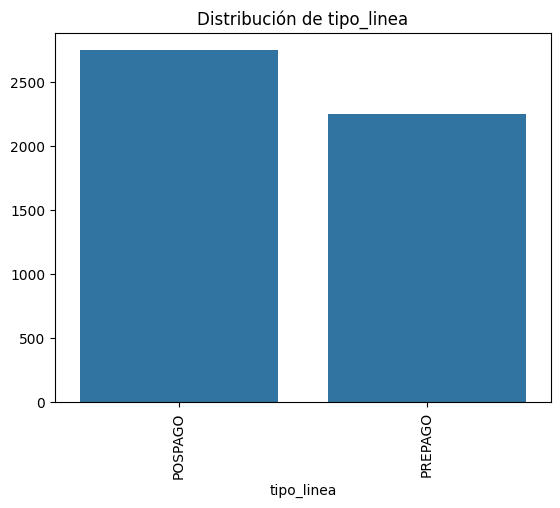

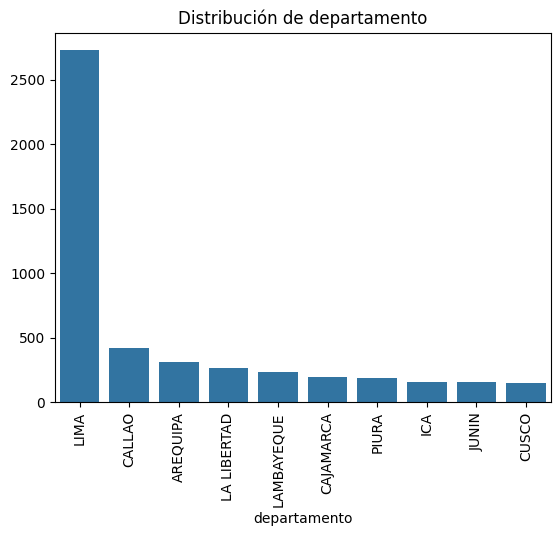

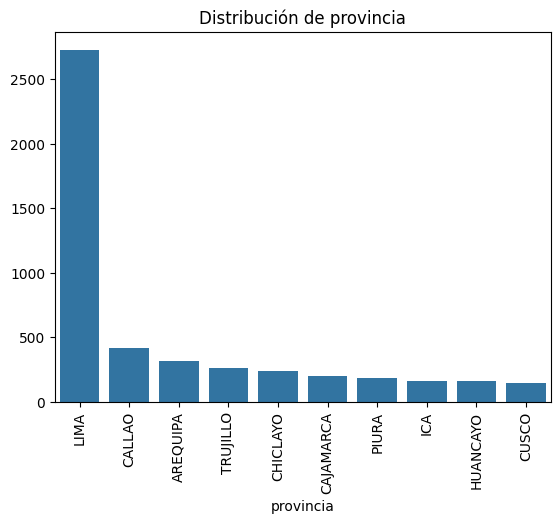

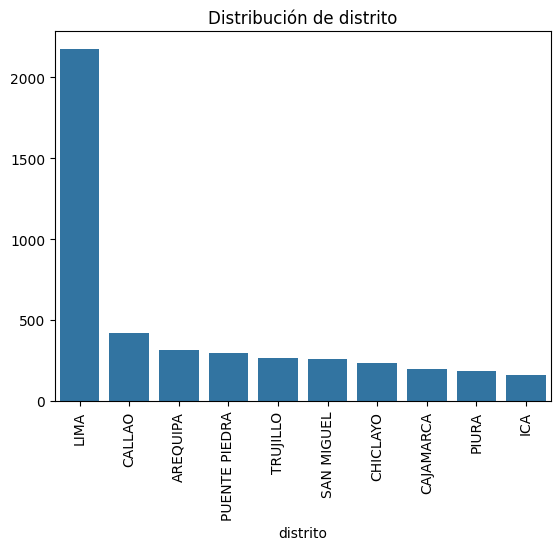

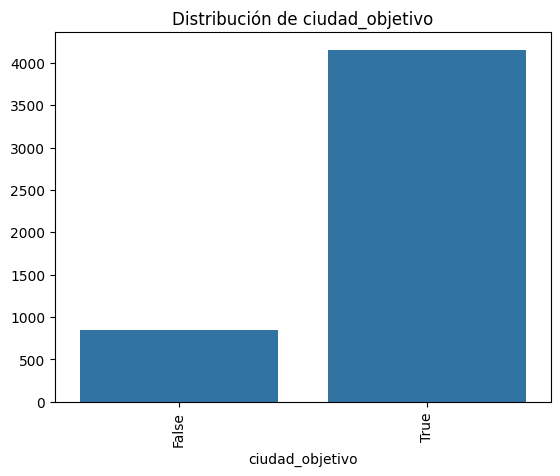

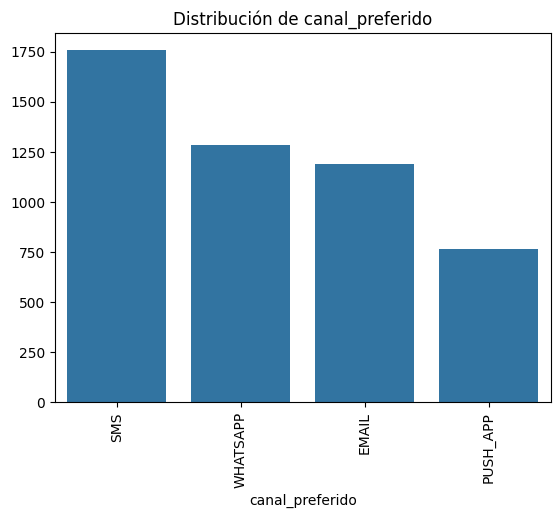

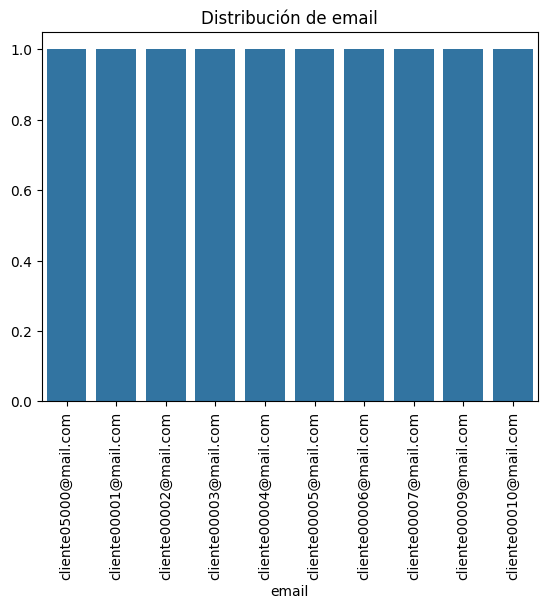

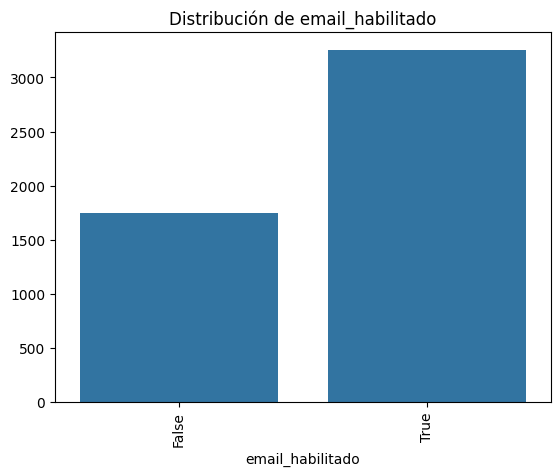

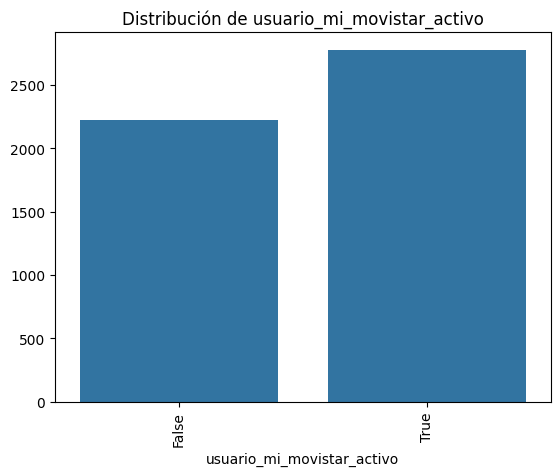

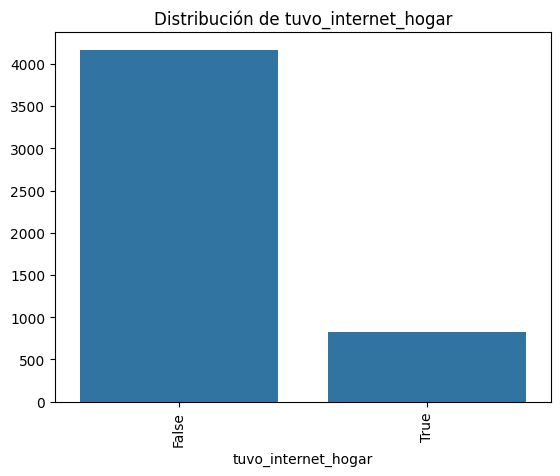

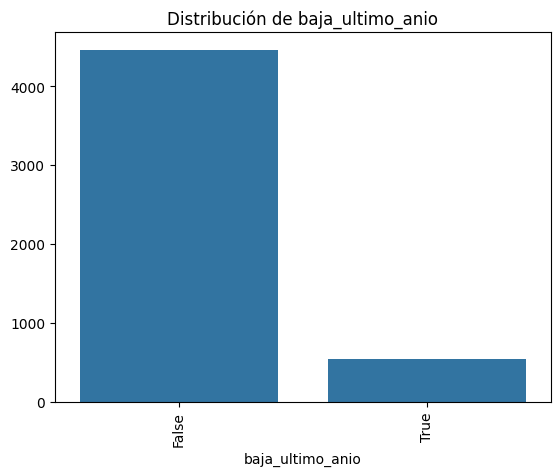

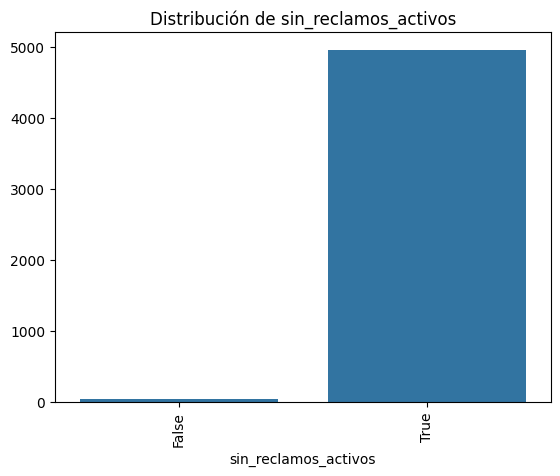

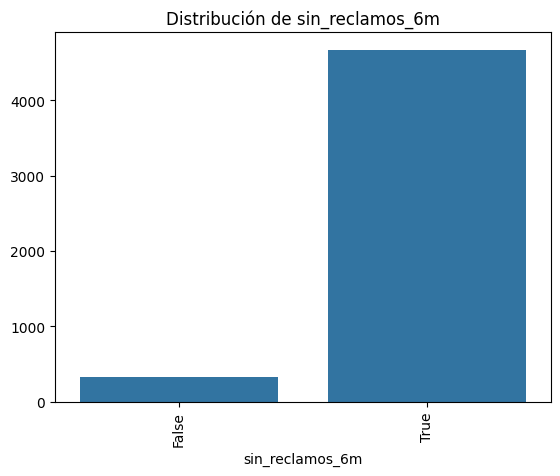

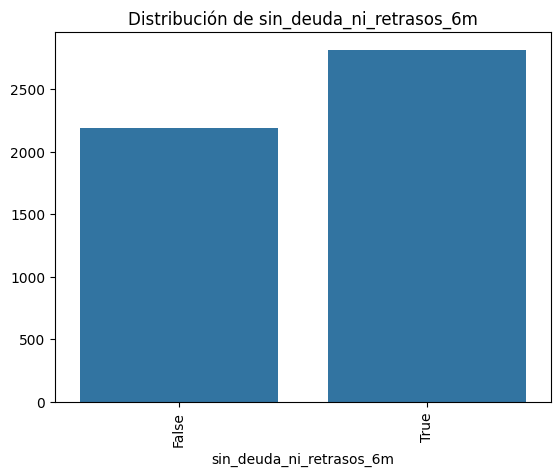

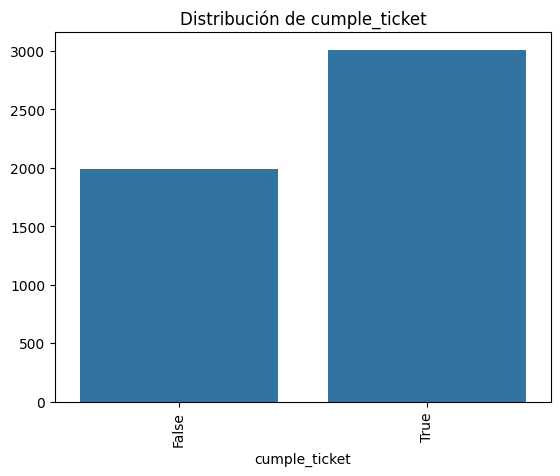

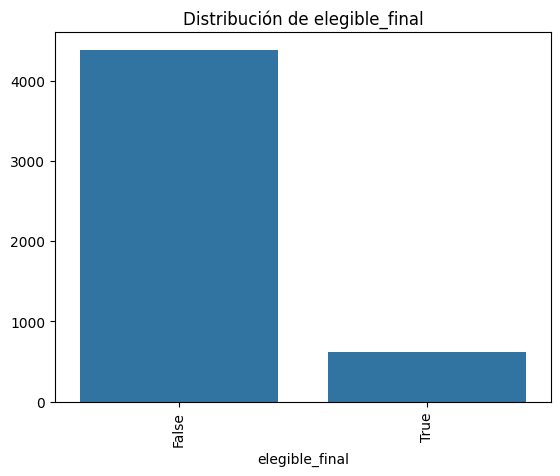

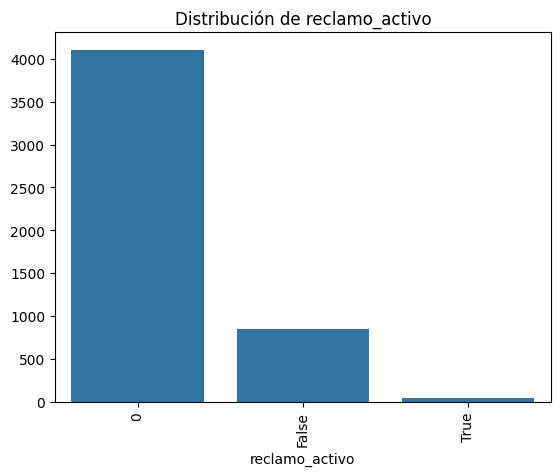

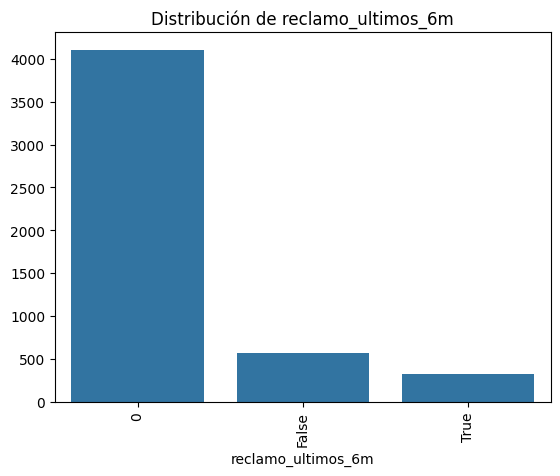

In [ ]:
# Gráficos de barras

import matplotlib.pyplot as plt
import seaborn as sns

for col in variables_categoricas:
    plt.figure()
    top_categories = dataset_clientes[col].value_counts().nlargest(10)
    sns.barplot(x=top_categories.index, y=top_categories.values)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=90)
    plt.show()


Al analizar las variables categóricas, observamos patrones clave en la distribución de clientes:

*   **`tipo_linea`**: La base de clientes está bastante equilibrada, con un ligero predominio de POSPAGO (54.96%) sobre PREPAGO (45.04%). Esto es crucial para entender los perfiles de gasto.
*   **Ubicación Geográfica (`departamento`, `provincia`, `distrito`)**: LIMA es dominante en todas las categorías, concentrando más del 50% de los clientes en departamento y provincia, y un 43.48% en distrito. Esto indica una alta concentración del mercado en la capital, lo que es vital para la estrategia de expansión de Internet Hogar.
*   **`ciudad_objetivo`**: La gran mayoría de los clientes (83.1%) se encuentran en una ciudad objetivo. Esto sugiere un buen alineamiento entre la base actual de clientes y el enfoque estratégico de la empresa.
*   **`canal_preferido`**: SMS (35.14%) es el canal de comunicación más preferido, seguido por WHATSAPP (25.7%). Esta información es esencial para optimizar las campañas de marketing y comunicación, asegurando que los mensajes lleguen por la vía más efectiva.

Estos resultados nos permiten comprender mejor la composición de nuestra base de clientes, identificar mercados clave (como Lima), validar la efectividad de la estrategia (`ciudad_objetivo`), y optimizar las tácticas de comunicación, lo cual es fundamental para cualquier modelo de segmentación o recomendación.

###### **3.1.3.2.3. Distribucion tipo de linea***

In [ ]:
# Tipo de línea
dataset_clientes['tipo_linea'].value_counts(normalize=True) * 100


,proportion
tipo_linea,
POSPAGO,54.96
PREPAGO,45.04


**Conclusión:** la distribución de `tipo_linea`, concluimos que la base de clientes está bastante equilibrada, con un ligero predominio de POSPAGO (54.96%) sobre PREPAGO (45.04%). Este balance es crucial para entender que ambos segmentos son significativos, lo que influirá en el desarrollo de estrategias de marketing diferenciadas y en el análisis de patrones de consumo para cada tipo de cliente.

###### **3.1.3.2.4. Deuda actual**

In [ ]:
#Deuda actual
dataset_clientes['deuda_actual'].describe()


,deuda_actual
count,5000.000000
mean,18.925414
std,40.555879
min,0.000000
25%,0.000000
50%,0.000000
75%,15.507500
max,317.680000


**Conclusión:** al menos el 50% de los clientes no tiene deuda, pero un pequeño grupo presenta deudas elevadas (hasta 317.68), lo que eleva la media y genera alta variabilidad. Esto indica un fuerte sesgo a la derecha y la presencia de outliers, crucial para enfocar estrategias de riesgo y segmentación.

###### **3.1.3.2.5. Antigüedad**

In [ ]:
# Antigüedad
dataset_clientes['antiguedad_meses'].describe()


,antiguedad_meses
count,5000.000000
mean,12.381800
std,11.151507
min,0.000000
25%,3.000000
50%,8.000000
75%,22.000000
max,36.000000


**Conclusión:** La mayoría de nuestros clientes son relativamente nuevos (mediana de 8 meses), pero existe una buena variabilidad hasta los 36 meses. Esto es crucial para segmentar a los clientes por su ciclo de vida y diseñar estrategias de retención diferenciadas.

###### **3.1.3.2.6. Reclamos**

In [ ]:
# Reclamos
dataset_clientes['reclamos_totales'].describe()


,reclamos_totales
count,5000.000000
mean,0.208800
std,0.482959
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,3.000000


**Conclusión:** La mayoría de los clientes no tienen reclamos (al menos el 75% tiene 0 reclamos). Sin embargo, la presencia de algunos clientes con hasta 3 reclamos (mean 0.20, std 0.48) nos alerta sobre un segmento minoritario pero crítico. Esto es clave para la gestión de la satisfacción y para identificar posibles puntos de mejora en el servicio o áreas de riesgo de abandono.

#### **3.1.4 Análisis de outliers**

##### **3.1.4.1. Boxplot por elegibilidad**

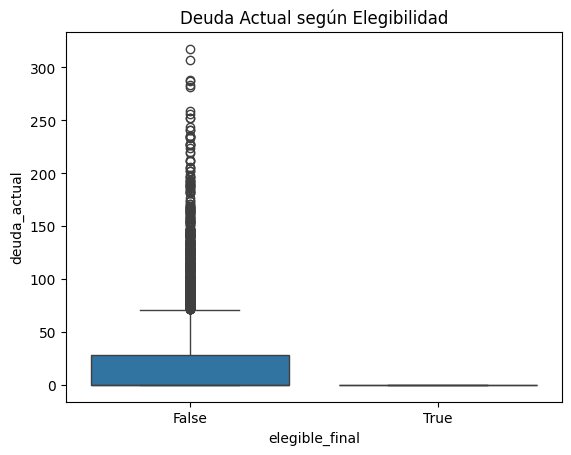

In [ ]:
# Deuda vs Elegibilidad
plt.figure()
sns.boxplot(x='elegible_final', y='deuda_actual', data=dataset_clientes)
plt.title("Deuda Actual según Elegibilidad")
plt.show()



Los clientes elegibles (True) presentan valores concentrados en cero, sin dispersión significativa ni presencia de valores extremos. Esto indica que los clientes seleccionados cumplen efectivamente con el criterio de no registrar deuda vigente.

Por el contrario, los clientes no elegibles (False) muestran una distribución altamente dispersa, con presencia de numerosos valores atípicos que alcanzan niveles elevados de deuda. La mediana cercana a cero junto con múltiples outliers evidencia una distribución fuertemente sesgada hacia la derecha, donde una proporción reducida de clientes concentra montos altos de deuda.

Este resultado valida que la deuda_actual es una variable determinante dentro del proceso de segmentación.


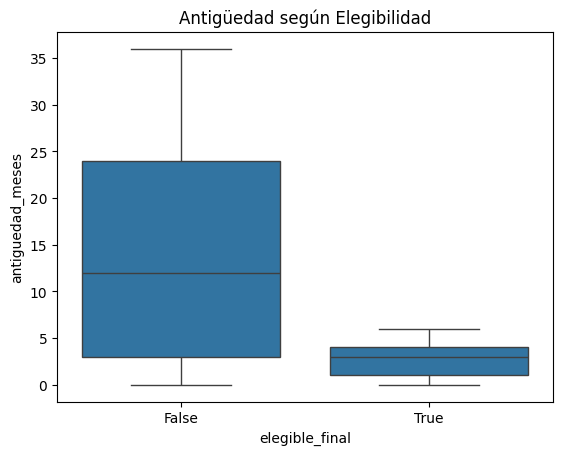

In [ ]:
# Antigüedad vs Elegibilidad
plt.figure()
sns.boxplot(x='elegible_final', y='antiguedad_meses', data=dataset_clientes)
plt.title("Antigüedad según Elegibilidad")
plt.show()


En el caso de antiguedad_meses, se observa que los clientes elegibles presentan una distribución concentrada en valores bajos, con menor dispersión y un rango reducido. Esto es consistente con el criterio definido en los objetivos específicos, donde se establece un límite de antigüedad menor o igual a seis meses.

En contraste, los clientes no elegibles presentan una mayor variabilidad y un rango más amplio de antigüedad, incluyendo clientes con varios años de permanencia en la empresa.

La diferencia en mediana y rango intercuartílico entre ambos grupos confirma que la variable antigüedad_meses tiene un impacto directo en la clasificación final de elegibilidad.

#### **3.1.5. Análisis de outliers del dataframe**

Estos resultados demuestran coherencia entre los criterios de negocio definidos en la etapa de planteamiento del problema y el comportamiento real de los datos, fortaleciendo la validez del proceso de segmentación implementado.

Se debe analizar el % de valores nulos:
- Si es muy pequeño el % de valores nulos se pueden eliminar los nulos.
- Si no es tan grande el % de valores nulos hay que analizar imputar los valores nulos por la mediana o moda u otras opciones (dependiendo del tipo de variable).
- Si es grande el % de nulos, lo mejor es no usar esa variable.

##### **3.1.5.1. Verificación de valores nulos por variable**




In [ ]:
# Función para calcular porcentaje de valores nulos
def porcentaje_nulos(dataframe):

    total = dataframe.isnull().sum()
    porcentaje = (total / len(dataframe)) * 100

    resumen = pd.DataFrame({
        'Total_Nulos': total,
        'Porcentaje_Nulos': porcentaje
    })

    return resumen.sort_values(by='Porcentaje_Nulos', ascending=False)


In [ ]:
resumen_nulos = porcentaje_nulos(dataset_clientes)
resumen_nulos



,Total_Nulos,Porcentaje_Nulos
fecha_baja_internet_hogar,4169,83.38
promedio_recarga_mensual,2748,54.96
mensualidad_pospago,2252,45.04
email,1161,23.22
tipo_linea,0,0.00
fecha_alta_movil,0,0.00
departamento,0,0.00
distrito,0,0.00
provincia,0,0.00
antiguedad_meses,0,0.00


In [ ]:
dataset_clientes.shape


(5000, 27)

Observamos:

*   **Altos Porcentajes de Nulos:** `fecha_baja_internet_hogar` (83.38%), `promedio_recarga_mensual` (54.96%) y `mensualidad_pospago` (45.04%) presentan un volumen muy alto de valores nulos. `email` (23.22%) también es considerable.
*   **Columnas Completas:** La gran mayoría de las otras columnas (como `id_cliente`, `tipo_linea`, `antiguedad_meses`, etc.) no tienen ningún valor nulo (0.00%).

Nos indican que las columnas con más del 40-50% de nulos (`fecha_baja_internet_hogar`, `promedio_recarga_mensual`, `mensualidad_pospago`) son candidatas a ser eliminadas o tratadas de forma muy específica (ej. crear una variable indicadora de nulo). Para `email`, con un 23%, podemos considerar imputación si es relevante.

#####**3.1.5.2. Eliminando registros o variables según presencia de nulos**

In [ ]:
columnas_eliminar = resumen_nulos[
    resumen_nulos['Porcentaje_Nulos'] > 40
].index

dataset_clientes.drop(columnas_eliminar, axis=1, inplace=True)

dataset_clientes.shape


(5000, 24)

Eliminamos las columnas con más del 40% de valores nulos (`fecha_baja_internet_hogar`, `promedio_recarga_mensual`, `mensualidad_pospago`) porque un volumen tan alto los hace poco útiles. Confirmamos la eliminación verificando el nuevo `shape` del DataFrame (`(5000, 25)`) y volviendo a calcular el porcentaje de nulos. Este proceso es crucial para limpiar el dataset y asegurar la calidad de los datos para el modelado, dejando solo `email` con nulos para un tratamiento posterior.

In [ ]:
porcentaje_nulos(dataset_clientes)


,Total_Nulos,Porcentaje_Nulos
email,1161,23.22
id_cliente,0,0.00
fecha_alta_movil,0,0.00
tipo_linea,0,0.00
departamento,0,0.00
provincia,0,0.00
distrito,0,0.00
antiguedad_meses,0,0.00
ciudad_objetivo,0,0.00
deuda_actual,0,0.00


### **3.2 Análisis de Target**

#### **3.2.1 Distribución del target y desbalance de clases**

La variable objetivo `elegible_final` presenta un marcado desbalance: la clase positiva (elegibles) representa el **12.28%** del dataset (614 de 5,000 registros). Este desbalance es determinante para las decisiones de modelado — se requiere compensación de clases en todos los modelos.

Distribución de la variable objetivo:
  False:  4386 registros (87.72%)
  True:   614 registros (12.28%)


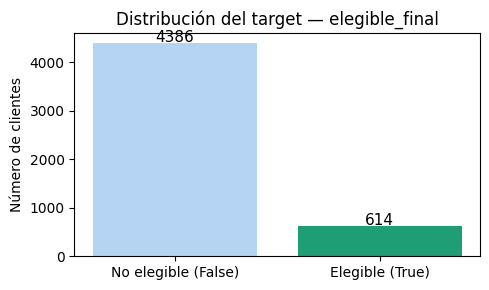

In [ ]:
conteo = dataset_clientes['elegible_final'].value_counts()
pct    = dataset_clientes['elegible_final'].value_counts(normalize=True) * 100

print("Distribución de la variable objetivo:")
for val in conteo.index:
    print(f"  {val}: {conteo[val]:>5} registros ({pct[val]:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No elegible (False)', 'Elegible (True)'],
       conteo.values, color=['#B5D4F4', '#1D9E75'])
ax.set_title('Distribución del target — elegible_final')
ax.set_ylabel('Número de clientes')
for i, v in enumerate(conteo.values):
    ax.text(i, v + 30, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


#### **3.2.2 Limpieza de columnas con valores mixtos**

Las columnas `reclamo_activo` y `reclamo_ultimos_6m` contienen valores mixtos (`'True'`, `'False'`, `'0'`) que deben normalizarse antes de cualquier análisis.

In [ ]:
# Convertir target a numérico
dataset_clientes['elegible_final_num'] = dataset_clientes['elegible_final'].astype(int)

# Corregir columnas con valores mixtos string/bool
for col in ['reclamo_activo', 'reclamo_ultimos_6m']:
    dataset_clientes[col] = dataset_clientes[col].map(
        {'True': True, 'False': False, '0': False, 0: False}
    ).astype(bool)

print("Columnas corregidas: reclamo_activo, reclamo_ultimos_6m")
print(f"  reclamo_activo unique:     {dataset_clientes['reclamo_activo'].unique()}")
print(f"  reclamo_ultimos_6m unique: {dataset_clientes['reclamo_ultimos_6m'].unique()}")


Columnas corregidas: reclamo_activo, reclamo_ultimos_6m
  reclamo_activo unique:     [False  True]
  reclamo_ultimos_6m unique: [False  True]


#### **3.2.3 Detección de Data Leakage y selección de features**

Al calcular la correlación de todas las variables con el target se detectó un problema
crítico: varias columnas booleanas tienen correlación perfecta o casi perfecta porque
son **criterios derivados de la misma regla que construye `elegible_final`**.

Incluirlas como features produce métricas artificialmente perfectas (1.0 en todo),
lo que no refleja capacidad predictiva real — el modelo simplemente memoriza la fórmula
con la que se construyó el target.

La regla detectada que reconstruye el target con 100% de exactitud es:

```
elegible_final = True  si:
  antiguedad_meses <= 6
  AND deuda_actual == 0  AND retrasos_6m == 0
  AND cumple_ticket == True  AND ciudad_objetivo == True
  AND sin_reclamos_6m == True
  AND baja_ultimo_anio == False  AND reclamo_ultimos_6m == False
```

Por eso se descartan todas las variables derivadas y se trabaja únicamente con
las **7 variables crudas** disponibles antes de aplicar cualquier criterio de elegibilidad:

| Variable | Tipo | Justificación |
|---|---|---|
| `antiguedad_meses` | Numérica | Variable cruda del cliente |
| `deuda_actual` | Numérica | Variable cruda del cliente |
| `retrasos_6m` | Numérica | Variable cruda del cliente |
| `reclamos_totales` | Numérica | Historial crudo del cliente |
| `usuario_mi_movistar_activo` | Booleana | Comportamiento independiente del target |
| `email_habilitado` | Booleana | Contactabilidad independiente del target |
| `tuvo_internet_hogar` | Booleana | Historial independiente del target |

In [ ]:
# Verificación del leakage detectado
df_check = dataset_clientes.copy()
for c in df_check.select_dtypes(include='bool').columns:
    df_check[c] = df_check[c].astype(int)

num_cols = df_check.select_dtypes(include=['int64','float64']).columns
corr_target = (
    df_check[num_cols]
    .corr()['elegible_final_num']
    .drop('elegible_final_num')
    .abs()
    .sort_values(ascending=False)
)

print("Correlación absoluta con el target (todas las variables):")
display(corr_target.reset_index().rename(
    columns={'index': 'Variable', 'elegible_final_num': '|Correlación|'}
))


Correlación absoluta con el target (todas las variables):


,Variable,|Correlación|
0,elegible_final,1.000000
1,sin_deuda_ni_retrasos_6m,0.329637
2,antiguedad_meses,0.329126
3,cumple_ticket,0.304224
4,retrasos_6m,0.181753
5,deuda_actual,0.174616
6,ciudad_objetivo,0.168730
7,baja_ultimo_anio,0.129649
8,reclamo_ultimos_6m,0.098813
9,sin_reclamos_6m,0.098813


In [ ]:
# Confirmación del leakage: las variables derivadas reconstruyen el target
elegibles = dataset_clientes[dataset_clientes['elegible_final'] == True]

print("Verificación — valores en clientes ELEGIBLES:")
print(f"  deuda_actual  == 0 siempre: {(elegibles['deuda_actual'] == 0).all()}")
print(f"  retrasos_6m   == 0 siempre: {(elegibles['retrasos_6m'] == 0).all()}")
print(f"  cumple_ticket == True siempre: {elegibles['cumple_ticket'].all()}")
print(f"  ciudad_objetivo == True siempre: {elegibles['ciudad_objetivo'].all()}")
print(f"  baja_ultimo_anio == False siempre: {(~elegibles['baja_ultimo_anio']).all()}")
print(f"  rango antiguedad_meses: {elegibles['antiguedad_meses'].min()} a {elegibles['antiguedad_meses'].max()}")
print()
print("Conclusión: estas variables son criterios del target, no predictores independientes.")
print("Se excluyen del entrenamiento para evitar data leakage.")


Verificación — valores en clientes ELEGIBLES:
  deuda_actual  == 0 siempre: True
  retrasos_6m   == 0 siempre: True
  cumple_ticket == True siempre: True
  ciudad_objetivo == True siempre: True
  baja_ultimo_anio == False siempre: True
  rango antiguedad_meses: 0 a 6

Conclusión: estas variables son criterios del target, no predictores independientes.
Se excluyen del entrenamiento para evitar data leakage.


#### **3.2.4 Definición de features y escalado**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Features limpias: solo variables crudas disponibles en producción
FEATURES = [
    'antiguedad_meses',
    'deuda_actual',
    'retrasos_6m',
    'reclamos_totales',
    'usuario_mi_movistar_activo',
    'email_habilitado',
    'tuvo_internet_hogar',
]
TARGET = 'elegible_final_num'

print(f"Features seleccionadas: {len(FEATURES)}")
for f in FEATURES:
    print(f"  {f:<35} dtype: {dataset_clientes[f].dtype}")

# Escalar variables numéricas continuas
vars_escalar = ['antiguedad_meses', 'deuda_actual', 'retrasos_6m']
scaler = StandardScaler()
dataset_clientes[vars_escalar] = scaler.fit_transform(dataset_clientes[vars_escalar])

print()
print("Verificación post-escalado (media ≈ 0, std ≈ 1):")
display(dataset_clientes[vars_escalar].describe().round(4))


Features seleccionadas: 7
  antiguedad_meses                    dtype: int64
  deuda_actual                        dtype: float64
  retrasos_6m                         dtype: int64
  reclamos_totales                    dtype: float64
  usuario_mi_movistar_activo          dtype: bool
  email_habilitado                    dtype: bool
  tuvo_internet_hogar                 dtype: bool

Verificación post-escalado (media ≈ 0, std ≈ 1):


,antiguedad_meses,deuda_actual,retrasos_6m
count,5000.0000,5000.0000,5000.0000
mean,-0.0000,-0.0000,-0.0000
std,1.0001,1.0001,1.0001
min,-1.1104,-0.4667,-0.4858
25%,-0.8414,-0.4667,-0.4858
50%,-0.3930,-0.4667,-0.4858
75%,0.8626,-0.0843,-0.4858
max,2.1181,7.3672,3.7979


## 4. Modelos de Machine Learning

### Configuración del experimento

Todos los modelos utilizan el **mismo split train/test** (70/30, stratify, random_state=42)
y las mismas **7 features crudas** libres de leakage. El pipeline de cada modelo incluye
imputación por mediana y escalado estándar donde corresponde.

Con desbalance del ~12.28% en la clase positiva, todos los modelos incorporan
compensación de clases (`class_weight='balanced'` o `scale_pos_weight`).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve, auc
)

X = dataset_clientes[FEATURES].astype(float)
y = dataset_clientes[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas")
print(f"Features: {X.shape[1]}")
print(f"Proporción clase positiva — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")


Train: 3500 filas  |  Test: 1500 filas
Features: 7
Proporción clase positiva — Train: 0.123  |  Test: 0.123


### 4.1 Regresión Logística

Modelo lineal que estima la probabilidad de elegibilidad mediante una función sigmoide.
Altamente interpretable: los coeficientes revelan directamente el peso y dirección
de cada variable. Se usa `class_weight='balanced'` para compensar el desbalance.

── Regresión Logística ──────────────────────────────────────────────────
  ROC AUC  — Train: 0.9258  | Test: 0.9268
  Accuracy — Train: 0.8383  | Test: 0.8287
  Recall   — Train: 0.9814  | Test: 0.9511
  Precision— Train: 0.4306  | Test: 0.4137

Reporte de clasificación (Test):
              precision    recall  f1-score   support

 No elegible       0.99      0.81      0.89      1316
    Elegible       0.41      0.95      0.58       184

    accuracy                           0.83      1500
   macro avg       0.70      0.88      0.73      1500
weighted avg       0.92      0.83      0.85      1500



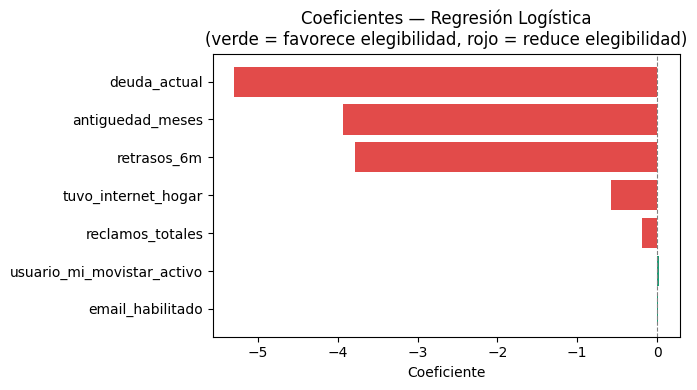

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
pipe_lr.fit(X_train, y_train)

proba_lr_train = pipe_lr.predict_proba(X_train)[:, 1]
proba_lr_test  = pipe_lr.predict_proba(X_test)[:, 1]
pred_lr_train  = pipe_lr.predict(X_train)
pred_lr_test   = pipe_lr.predict(X_test)

print("── Regresión Logística ──────────────────────────────────────────────────")
print(f"  ROC AUC  — Train: {roc_auc_score(y_train, proba_lr_train):.4f}  | Test: {roc_auc_score(y_test, proba_lr_test):.4f}")
print(f"  Accuracy — Train: {accuracy_score(y_train, pred_lr_train):.4f}  | Test: {accuracy_score(y_test, pred_lr_test):.4f}")
print(f"  Recall   — Train: {recall_score(y_train, pred_lr_train):.4f}  | Test: {recall_score(y_test, pred_lr_test):.4f}")
print(f"  Precision— Train: {precision_score(y_train, pred_lr_train, zero_division=0):.4f}  | Test: {precision_score(y_test, pred_lr_test, zero_division=0):.4f}")
print()
print("Reporte de clasificación (Test):")
print(classification_report(y_test, pred_lr_test, target_names=['No elegible', 'Elegible']))

coef_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coeficiente': pipe_lr.named_steps['model'].coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#E24B4A' if c < 0 else '#1D9E75' for c in coef_df['Coeficiente']]
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colores)
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_title('''Coeficientes — Regresión Logística
(verde = favorece elegibilidad, rojo = reduce elegibilidad)''')
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

### 4.2 Árbol de Decisiones

Genera reglas de clasificación jerárquicas y explícitas. Se limita la profundidad
(`max_depth=7`) para evitar sobreajuste. La visualización del árbol permite leer
directamente las reglas de negocio aprendidas por el modelo.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42))
])
pipe_dt.fit(X_train, y_train)

proba_dt_train = pipe_dt.predict_proba(X_train)[:, 1]
proba_dt_test  = pipe_dt.predict_proba(X_test)[:, 1]
pred_dt_train  = pipe_dt.predict(X_train)
pred_dt_test   = pipe_dt.predict(X_test)

print("── Árbol de Decisiones ──────────────────────────────────────────────────")
print(f"  ROC AUC  — Train: {roc_auc_score(y_train, proba_dt_train):.4f}  | Test: {roc_auc_score(y_test, proba_dt_test):.4f}")
print(f"  Accuracy — Train: {accuracy_score(y_train, pred_dt_train):.4f}  | Test: {accuracy_score(y_test, pred_dt_test):.4f}")
print(f"  Recall   — Train: {recall_score(y_train, pred_dt_train):.4f}  | Test: {recall_score(y_test, pred_dt_test):.4f}")
print(f"  Precision— Train: {precision_score(y_train, pred_dt_train, zero_division=0):.4f}  | Test: {precision_score(y_test, pred_dt_test, zero_division=0):.4f}")
print()
print("Reporte de clasificación (Test):")
print(classification_report(y_test, pred_dt_test, target_names=['No elegible', 'Elegible']))


── Árbol de Decisiones ──────────────────────────────────────────────────
  ROC AUC  — Train: 0.9340  | Test: 0.9206
  Accuracy — Train: 0.8651  | Test: 0.8513
  Recall   — Train: 0.9814  | Test: 0.9457
  Precision— Train: 0.4763  | Test: 0.4496

Reporte de clasificación (Test):
              precision    recall  f1-score   support

 No elegible       0.99      0.84      0.91      1316
    Elegible       0.45      0.95      0.61       184

    accuracy                           0.85      1500
   macro avg       0.72      0.89      0.76      1500
weighted avg       0.92      0.85      0.87      1500



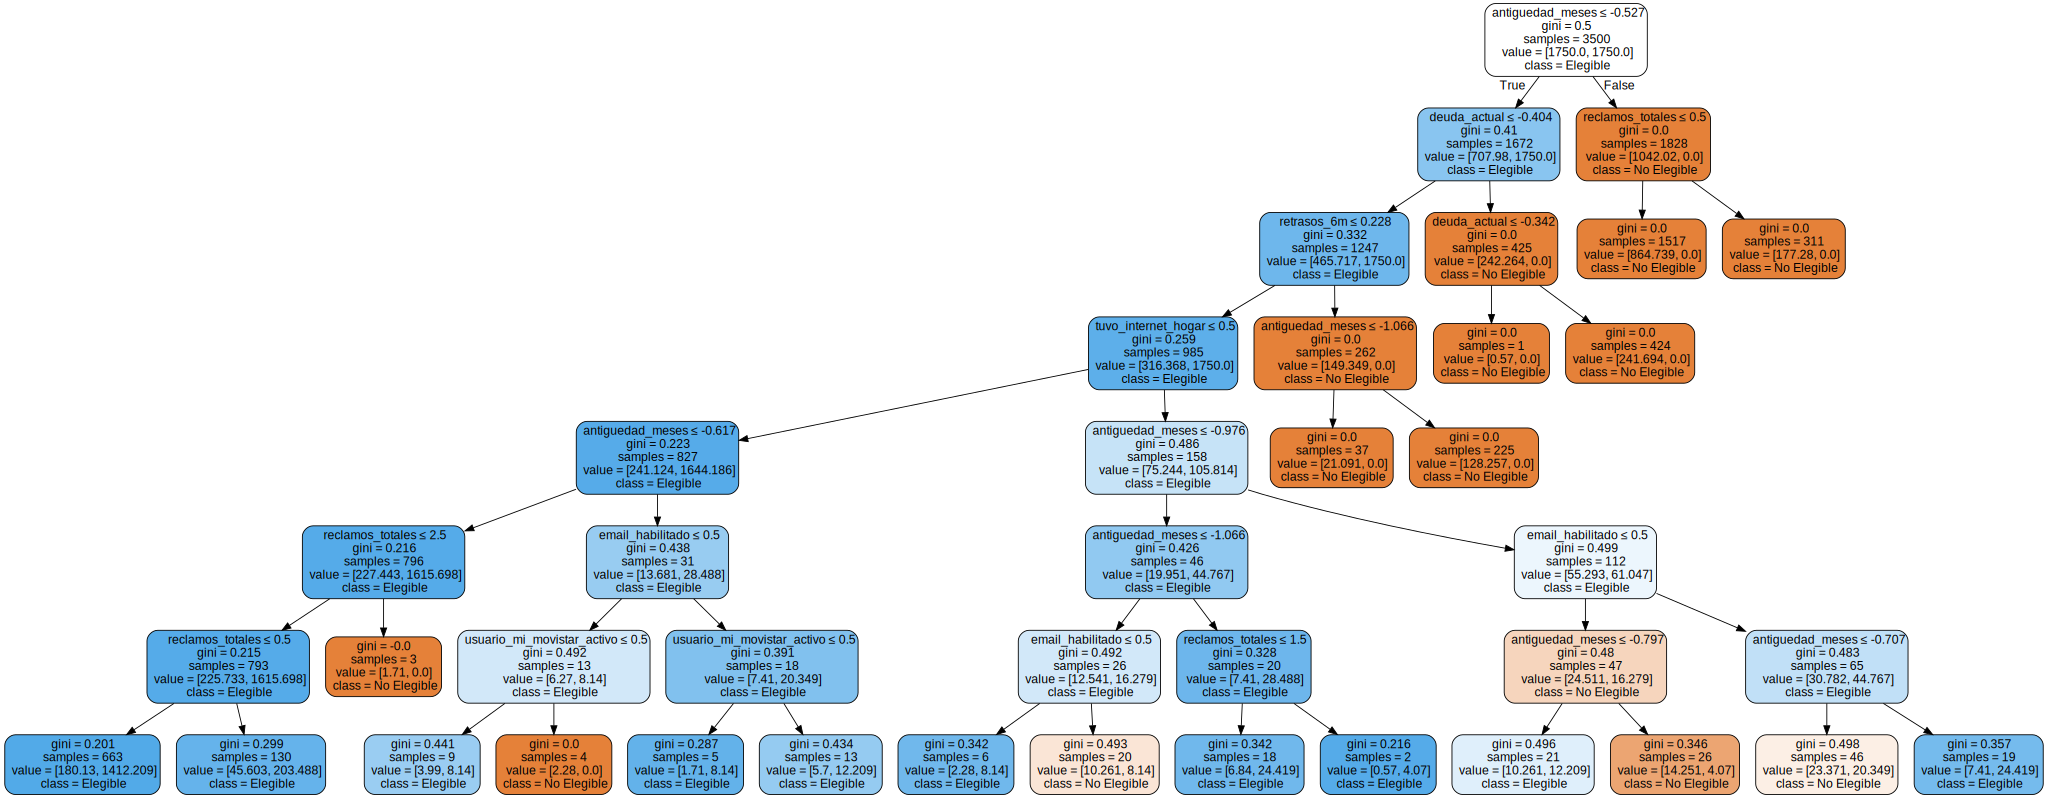

In [ ]:
!pip install graphviz -q
import graphviz
from sklearn import tree as sktree

dot_data = sktree.export_graphviz(
    pipe_dt.named_steps['model'],
    out_file=None,
    feature_names=FEATURES,
    class_names=['No Elegible', 'Elegible'],
    filled=True, rounded=True, special_characters=True
)
graphviz.Source(dot_data)


### 4.3 XGBoost

Gradient boosting secuencial donde cada árbol corrige los errores del anterior.
Uno de los algoritmos más potentes para datos tabulares. Se usa `scale_pos_weight`
calculado automáticamente del ratio de clases del conjunto de entrenamiento.

── XGBoost ──────────────────────────────────────────────────────────────
  ROC AUC  — Train: 0.9500  | Test: 0.9224
  Accuracy — Train: 0.8726  | Test: 0.8567
  Recall   — Train: 0.9977  | Test: 0.9130
  Precision— Train: 0.4908  | Test: 0.4578

Reporte de clasificación (Test):
              precision    recall  f1-score   support

 No elegible       0.99      0.85      0.91      1316
    Elegible       0.46      0.91      0.61       184

    accuracy                           0.86      1500
   macro avg       0.72      0.88      0.76      1500
weighted avg       0.92      0.86      0.88      1500



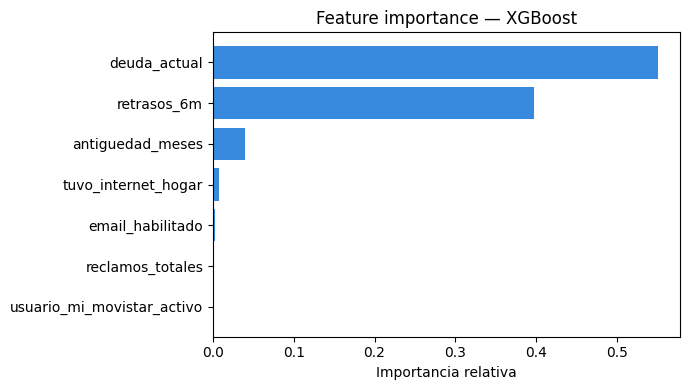

In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

scale_w = (y_train == 0).sum() / (y_train == 1).sum()

pipe_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBClassifier(scale_pos_weight=scale_w, eval_metric='logloss',
                               random_state=42, verbosity=0))
])
pipe_xgb.fit(X_train, y_train)

proba_xgb_train = pipe_xgb.predict_proba(X_train)[:, 1]
proba_xgb_test  = pipe_xgb.predict_proba(X_test)[:, 1]
pred_xgb_train  = pipe_xgb.predict(X_train)
pred_xgb_test   = pipe_xgb.predict(X_test)

print("── XGBoost ──────────────────────────────────────────────────────────────")
print(f"  ROC AUC  — Train: {roc_auc_score(y_train, proba_xgb_train):.4f}  | Test: {roc_auc_score(y_test, proba_xgb_test):.4f}")
print(f"  Accuracy — Train: {accuracy_score(y_train, pred_xgb_train):.4f}  | Test: {accuracy_score(y_test, pred_xgb_test):.4f}")
print(f"  Recall   — Train: {recall_score(y_train, pred_xgb_train):.4f}  | Test: {recall_score(y_test, pred_xgb_test):.4f}")
print(f"  Precision— Train: {precision_score(y_train, pred_xgb_train, zero_division=0):.4f}  | Test: {precision_score(y_test, pred_xgb_test, zero_division=0):.4f}")
print()
print("Reporte de clasificación (Test):")
print(classification_report(y_test, pred_xgb_test, target_names=['No elegible', 'Elegible']))

fi = pd.DataFrame({
    'Feature':     FEATURES,
    'Importancia': pipe_xgb.named_steps['model'].feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fi['Feature'], fi['Importancia'], color='#378ADD')
ax.set_title('Feature importance — XGBoost')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()


### 4.4 LightGBM

Variante de gradient boosting optimizada para velocidad y eficiencia en memoria.
Usa crecimiento de árbol *leaf-wise* en lugar de *level-wise*, capturando patrones
más complejos con menos iteraciones.

── LightGBM ─────────────────────────────────────────────────────────────
  ROC AUC  — Train: 0.9492  | Test: 0.9236
  Accuracy — Train: 0.8717  | Test: 0.8533
  Recall   — Train: 0.9977  | Test: 0.9076
  Precision— Train: 0.4892  | Test: 0.4514

Reporte de clasificación (Test):
              precision    recall  f1-score   support

 No elegible       0.98      0.85      0.91      1316
    Elegible       0.45      0.91      0.60       184

    accuracy                           0.85      1500
   macro avg       0.72      0.88      0.76      1500
weighted avg       0.92      0.85      0.87      1500



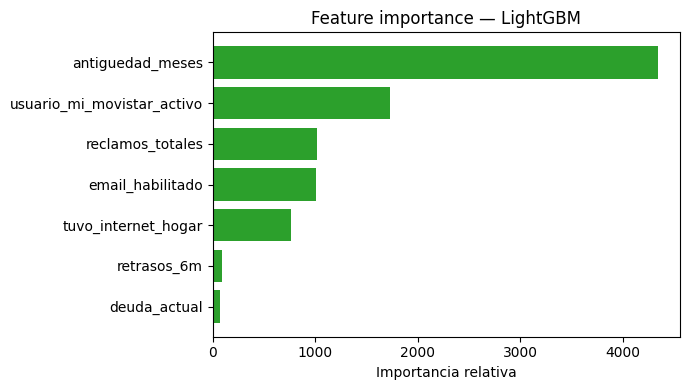

In [ ]:
!pip install lightgbm -q
import lightgbm as lgb

pipe_lgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                    class_weight='balanced', random_state=42, verbose=-1))
])
pipe_lgb.fit(X_train, y_train)

proba_lgb_train = pipe_lgb.predict_proba(X_train)[:, 1]
proba_lgb_test  = pipe_lgb.predict_proba(X_test)[:, 1]
pred_lgb_train  = pipe_lgb.predict(X_train)
pred_lgb_test   = pipe_lgb.predict(X_test)

print("── LightGBM ─────────────────────────────────────────────────────────────")
print(f"  ROC AUC  — Train: {roc_auc_score(y_train, proba_lgb_train):.4f}  | Test: {roc_auc_score(y_test, proba_lgb_test):.4f}")
print(f"  Accuracy — Train: {accuracy_score(y_train, pred_lgb_train):.4f}  | Test: {accuracy_score(y_test, pred_lgb_test):.4f}")
print(f"  Recall   — Train: {recall_score(y_train, pred_lgb_train):.4f}  | Test: {recall_score(y_test, pred_lgb_test):.4f}")
print(f"  Precision— Train: {precision_score(y_train, pred_lgb_train, zero_division=0):.4f}  | Test: {precision_score(y_test, pred_lgb_test, zero_division=0):.4f}")
print()
print("Reporte de clasificación (Test):")
print(classification_report(y_test, pred_lgb_test, target_names=['No elegible', 'Elegible']))

fi_lgb = pd.DataFrame({
    'Feature':     FEATURES,
    'Importancia': pipe_lgb.named_steps['model'].feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fi_lgb['Feature'], fi_lgb['Importancia'], color='#2ca02c')
ax.set_title('Feature importance — LightGBM')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()


## 5. Comparación de Modelos y Selección del Mejor

### 5.1 Curvas de diagnóstico global

Evaluamos cada modelo en todos sus posibles umbrales antes de fijar uno:

- **Curva Precision-Recall (AUC-PR):** métrica de referencia para datasets desbalanceados.
  No se infla por los verdaderos negativos — es la comparación correcta aquí.
- **Curva ROC:** métrica de discriminación global. Referencia secundaria.

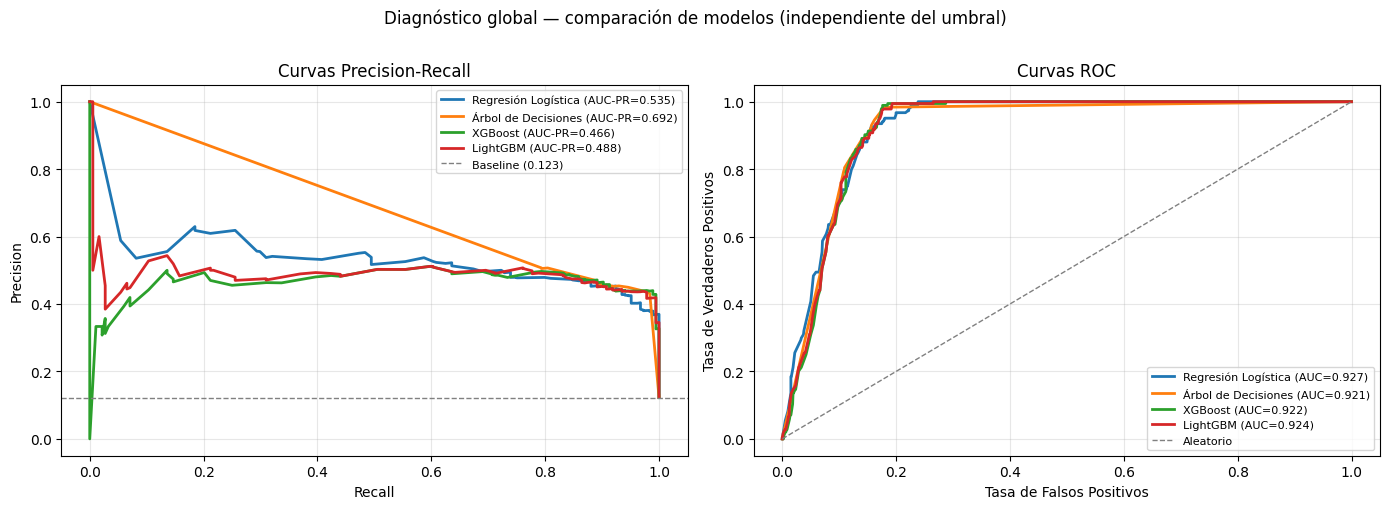

In [ ]:
modelos = {
    'Regresión Logística': proba_lr_test,
    'Árbol de Decisiones': proba_dt_test,
    'XGBoost':             proba_xgb_test,
    'LightGBM':            proba_lgb_test,
}
COLORES = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for (nombre, proba), color in zip(modelos.items(), COLORES):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, label=f'{nombre} (AUC-PR={auc(rec,prec):.3f})', color=color, lw=2)
ax.axhline(y_test.mean(), color='gray', ls='--', lw=1, label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for (nombre, proba), color in zip(modelos.items(), COLORES):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc(fpr,tpr):.3f})', color=color, lw=2)
ax.plot([0,1],[0,1], color='gray', ls='--', lw=1, label='Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos'); ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Diagnóstico global — comparación de modelos (independiente del umbral)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 5.2 Métrica de negocio y búsqueda del umbral óptimo

#### ¿Por qué no usar ROC AUC para seleccionar el modelo final?

El ROC AUC evalúa en todos los umbrales posibles simultáneamente. Es útil para
comparar capacidad discriminativa, pero no responde la pregunta operativa: ¿a partir
de qué probabilidad marcamos a un cliente como elegible?

#### Métrica elegida: F-beta (β=2)

Los errores tienen costos distintos para el negocio:

| Error | Significado | Costo |
|---|---|---|
| Falso Negativo (FN) | Perdemos un cliente elegible — venta perdida | **Alto** |
| Falso Positivo (FP) | Contactamos a alguien no elegible | Bajo |

F-beta con β=2 pondera Recall el doble que Precision. Para cada modelo se busca
el **umbral óptimo** que maximiza F-beta, en lugar de asumir el umbral por defecto de 0.5.

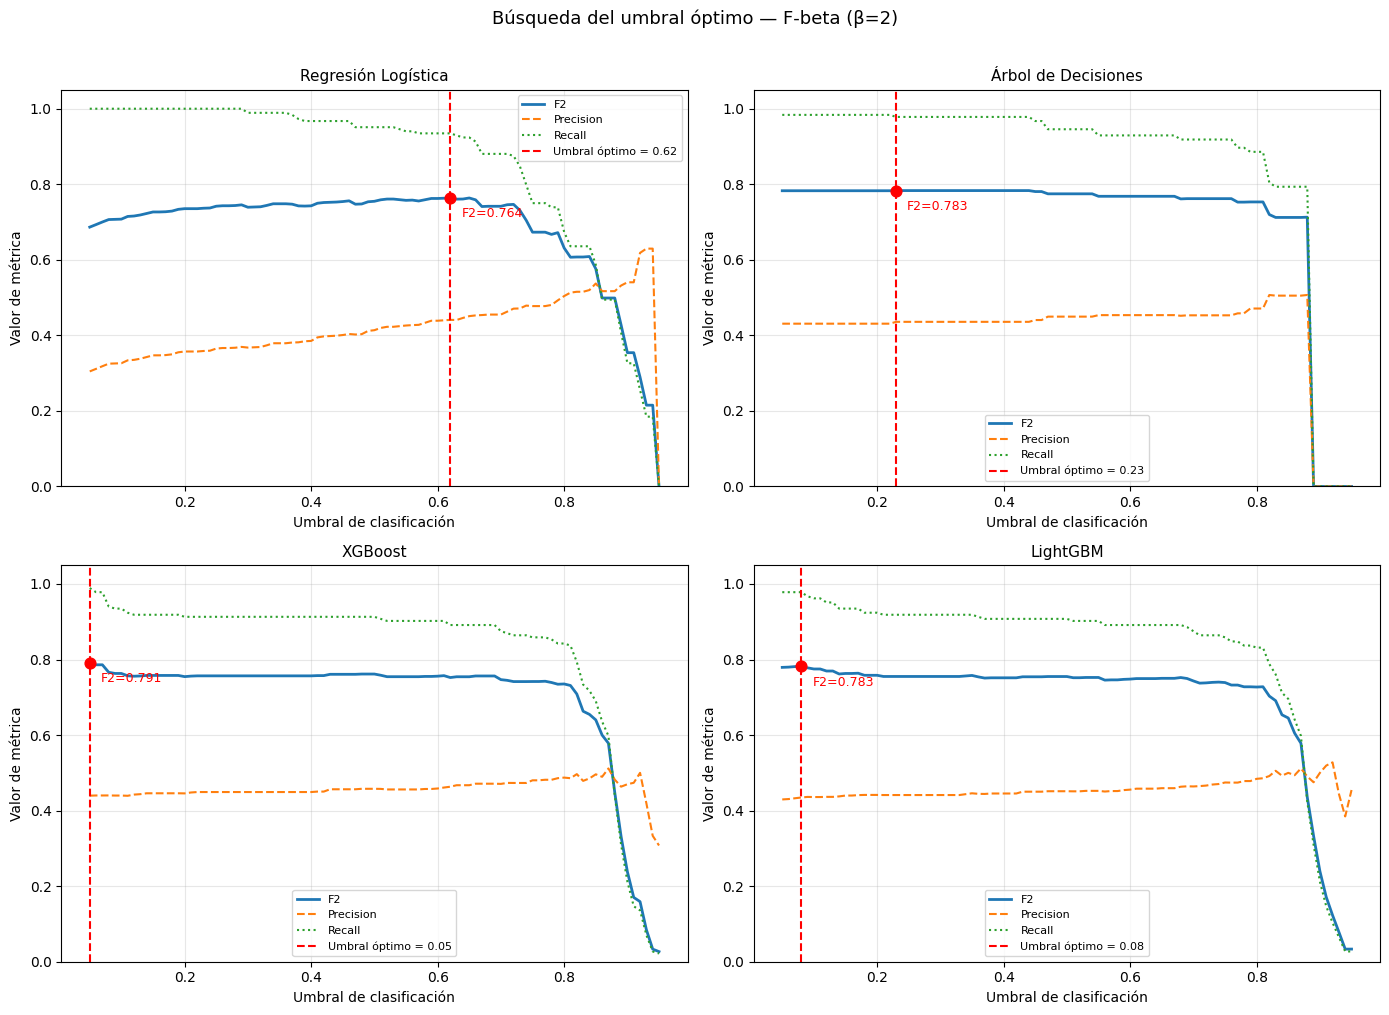

Umbrales óptimos encontrados:
  Regresión Logística           : 0.62
  Árbol de Decisiones           : 0.23
  XGBoost                       : 0.05
  LightGBM                      : 0.08


In [ ]:
BETA = 2

def buscar_umbral_optimo(y_true, y_proba, beta=BETA):
    umbrales = np.arange(0.05, 0.96, 0.01)
    rows = []
    for u in umbrales:
        y_pred = (y_proba >= u).astype(int)
        rows.append({
            'umbral':    round(u, 2),
            'fbeta':     fbeta_score(y_true, y_pred, beta=beta, zero_division=0),
            'f1':        f1_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall':    recall_score(y_true, y_pred, zero_division=0),
        })
    df_u = pd.DataFrame(rows)
    return df_u.loc[df_u['fbeta'].idxmax(), 'umbral'], df_u

umbrales_optimos = {}
curvas_umbral    = {}
for nombre, proba in modelos.items():
    u_opt, df_u = buscar_umbral_optimo(y_test, proba)
    umbrales_optimos[nombre] = u_opt
    curvas_umbral[nombre]    = df_u

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (nombre, proba) in enumerate(modelos.items()):
    df_u  = curvas_umbral[nombre]
    u_opt = umbrales_optimos[nombre]
    ax    = axes[idx]
    ax.plot(df_u['umbral'], df_u['fbeta'],     label=f'F{BETA}',   color='#1f77b4', lw=2)
    ax.plot(df_u['umbral'], df_u['precision'], label='Precision',  color='#ff7f0e', lw=1.5, ls='--')
    ax.plot(df_u['umbral'], df_u['recall'],    label='Recall',     color='#2ca02c', lw=1.5, ls=':')
    ax.axvline(x=u_opt, color='red', ls='--', lw=1.5, label=f'Umbral óptimo = {u_opt:.2f}')
    fb_opt = df_u.loc[df_u['umbral']==u_opt, 'fbeta'].values[0]
    ax.scatter([u_opt], [fb_opt], color='red', zorder=5, s=60)
    ax.annotate(f'F{BETA}={fb_opt:.3f}', (u_opt, fb_opt),
                textcoords='offset points', xytext=(8,-14), fontsize=9, color='red')
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Umbral de clasificación'); ax.set_ylabel('Valor de métrica')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)

plt.suptitle(f'Búsqueda del umbral óptimo — F-beta (β={BETA})', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Umbrales óptimos encontrados:")
for nombre, u in umbrales_optimos.items():
    print(f"  {nombre:<30}: {u:.2f}")


### 5.3 Tabla comparativa final — con umbral óptimo aplicado

In [ ]:
rows = []
for nombre, proba in modelos.items():
    u_opt  = umbrales_optimos[nombre]
    y_pred = (proba >= u_opt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total = tp + fp
    tasa  = tp / total if total > 0 else 0
    rows.append({
        'Modelo':              nombre,
        'Umbral':              u_opt,
        'Accuracy':            round(accuracy_score(y_test, y_pred), 4),
        'Precision':           round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':              round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':                  round(f1_score(y_test, y_pred, zero_division=0), 4),
        f'F{BETA} (criterio)': round(fbeta_score(y_test, y_pred, beta=BETA, zero_division=0), 4),
        'ROC AUC':             round(roc_auc_score(y_test, proba), 4),
        'TP': tp, 'FP': fp, 'FN': fn,
        'Tasa conversión':     f'{tasa:.1%}',
    })

df_final = pd.DataFrame(rows).set_index('Modelo')
df_final = df_final.sort_values(f'F{BETA} (criterio)', ascending=False)
display(df_final)

nombre_ganador = df_final[f'F{BETA} (criterio)'].idxmax()
print(f"\n→ Modelo ganador según F{BETA}: {nombre_ganador}")
print(f"  Umbral óptimo: {df_final.loc[nombre_ganador, 'Umbral']:.2f}")
print(f"  F{BETA}-score: {df_final.loc[nombre_ganador, f'F{BETA} (criterio)']:.4f}")


,Umbral,Accuracy,Precision,Recall,F1,F2 (criterio),ROC AUC,TP,FP,FN,Tasa conversión
Modelo,,,,,,,,,,,
XGBoost,0.05,0.8440,0.4396,0.9891,0.6087,0.7913,0.9224,182,232,2,44.0%
Árbol de Decisiones,0.23,0.8420,0.4358,0.9783,0.6030,0.7833,0.9206,180,233,4,43.6%
LightGBM,0.08,0.8413,0.4348,0.9783,0.6020,0.7826,0.9236,180,234,4,43.5%
Regresión Logística,0.62,0.8467,0.4410,0.9348,0.5993,0.7638,0.9268,172,218,12,44.1%



→ Modelo ganador según F2: XGBoost
  Umbral óptimo: 0.05
  F2-score: 0.7913


### 5.4 Análisis detallado del modelo ganador

In [ ]:
u_ganador      = umbrales_optimos[nombre_ganador]
proba_ganador  = modelos[nombre_ganador]
y_pred_ganador = (proba_ganador >= u_ganador).astype(int)

cm = confusion_matrix(y_test, y_pred_ganador)
tn, fp, fn, tp = cm.ravel()

print(f"Modelo seleccionado: {nombre_ganador}")
print(f"Umbral óptimo:       {u_ganador:.2f}")
print("=" * 60)
print(f"  Verdaderos Positivos (TP): {tp:>4}  — Elegibles identificados correctamente")
print(f"  Falsos Positivos    (FP): {fp:>4}  — No elegibles contactados por error")
print(f"  Falsos Negativos    (FN): {fn:>4}  — Elegibles no detectados (costo alto)")
print(f"  Verdaderos Negativos(TN): {tn:>4}  — No elegibles descartados correctamente")
print()
print(classification_report(y_test, y_pred_ganador, target_names=['No elegible', 'Elegible']))

total = tp + fp
tasa  = tp / total if total > 0 else 0
print("Impacto de negocio estimado:")
print(f"  Clientes recomendados para contactar: {total}")
print(f"  De esos, realmente elegibles:         {tp}  ({tasa:.1%} tasa de conversión esperada)")
print(f"  Elegibles no detectados:              {fn}")


Modelo seleccionado: XGBoost
Umbral óptimo:       0.05
  Verdaderos Positivos (TP):  182  — Elegibles identificados correctamente
  Falsos Positivos    (FP):  232  — No elegibles contactados por error
  Falsos Negativos    (FN):    2  — Elegibles no detectados (costo alto)
  Verdaderos Negativos(TN): 1084  — No elegibles descartados correctamente

              precision    recall  f1-score   support

 No elegible       1.00      0.82      0.90      1316
    Elegible       0.44      0.99      0.61       184

    accuracy                           0.84      1500
   macro avg       0.72      0.91      0.76      1500
weighted avg       0.93      0.84      0.87      1500

Impacto de negocio estimado:
  Clientes recomendados para contactar: 414
  De esos, realmente elegibles:         182  (44.0% tasa de conversión esperada)
  Elegibles no detectados:              2


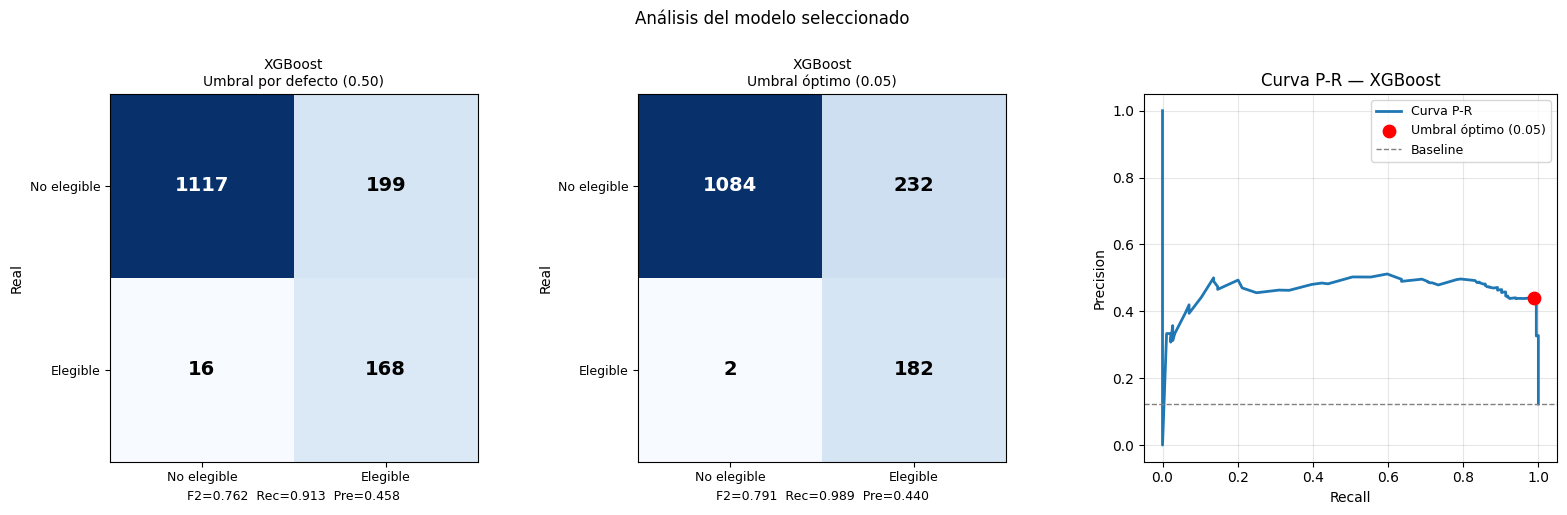

In [ ]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

for col_idx, (umbral, titulo) in enumerate(
    [(0.5, 'Umbral por defecto (0.50)'), (u_ganador, f'Umbral óptimo ({u_ganador:.2f})')]):
    ax = fig.add_subplot(gs[0, col_idx])
    ypred_tmp = (proba_ganador >= umbral).astype(int)
    cm_tmp    = confusion_matrix(y_test, ypred_tmp)
    thresh    = cm_tmp.max() / 2.0
    ax.imshow(cm_tmp, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{nombre_ganador}\n{titulo}', fontsize=10)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No elegible','Elegible'], fontsize=9)
    ax.set_yticklabels(['No elegible','Elegible'], fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_tmp[i, j]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm_tmp[i, j] > thresh else 'black')
    fb_v  = fbeta_score(y_test, ypred_tmp, beta=BETA, zero_division=0)
    rec_v = recall_score(y_test, ypred_tmp, zero_division=0)
    pre_v = precision_score(y_test, ypred_tmp, zero_division=0)
    ax.set_xlabel(f'F{BETA}={fb_v:.3f}  Rec={rec_v:.3f}  Pre={pre_v:.3f}', fontsize=9)
    ax.set_ylabel('Real')

ax3 = fig.add_subplot(gs[0, 2])
prec_c, rec_c, thr_c = precision_recall_curve(y_test, proba_ganador)
ax3.plot(rec_c, prec_c, color='#1f77b4', lw=2, label='Curva P-R')
idx_u = np.argmin(np.abs(thr_c - u_ganador))
ax3.scatter(rec_c[idx_u], prec_c[idx_u], color='red', s=80, zorder=5,
            label=f'Umbral óptimo ({u_ganador:.2f})')
ax3.axhline(y_test.mean(), color='gray', ls='--', lw=1, label='Baseline')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title(f'Curva P-R — {nombre_ganador}')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.suptitle('Análisis del modelo seleccionado', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 5.5 Validación cruzada estratificada — 5 folds

Un único split train/test puede ser sensible a cómo se dividieron los datos.
La **validación cruzada estratificada (5-fold)** evalúa cada modelo en 5 particiones
distintas del dataset, manteniendo la proporción de clases en cada fold.

Esto permite:
- Verificar que las métricas del split fijo no fueron casuales
- Medir la estabilidad del modelo (desviación estándar baja = modelo robusto)
- Detectar sobreajuste: si train >> val, el modelo memoriza en lugar de aprender

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

BETA = 2
f2_scorer = make_scorer(fbeta_score, beta=BETA, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisiones': pipe_dt,
    'XGBoost':             pipe_xgb,
    'LightGBM':            pipe_lgb,
}

resultados_cv = {}
print(f"Validación cruzada 5-fold — métrica principal F{BETA}\n")
print(f"{'Modelo':<25} {'F2 val (media)':<18} {'F2 val (std)':<16} {'Recall val':<16} {'Precision val'}")
print("-" * 95)

for nombre, pipe in modelos_cv.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={'f2': f2_scorer, 'recall': 'recall', 'precision': 'precision'},
        return_train_score=True
    )
    resultados_cv[nombre] = scores
    f2_mean = scores['test_f2'].mean()
    f2_std  = scores['test_f2'].std()
    rec     = scores['test_recall'].mean()
    pre     = scores['test_precision'].mean()
    print(f"  {nombre:<23} {f2_mean:.4f} ± {f2_std:.4f}    {rec:.4f} ± {scores['test_recall'].std():.4f}  {pre:.4f} ± {scores['test_precision'].std():.4f}")


Validación cruzada 5-fold — métrica principal F2

Modelo                    F2 val (media)     F2 val (std)     Recall val       Precision val
-----------------------------------------------------------------------------------------------
  Regresión Logística     0.7754 ± 0.0134    0.9744 ± 0.0225  0.4278 ± 0.0201
  Árbol de Decisiones     0.7857 ± 0.0090    0.9535 ± 0.0255  0.4624 ± 0.0191
  XGBoost                 0.7837 ± 0.0162    0.9395 ± 0.0298  0.4717 ± 0.0101
  LightGBM                0.7810 ± 0.0186    0.9349 ± 0.0350  0.4718 ± 0.0130


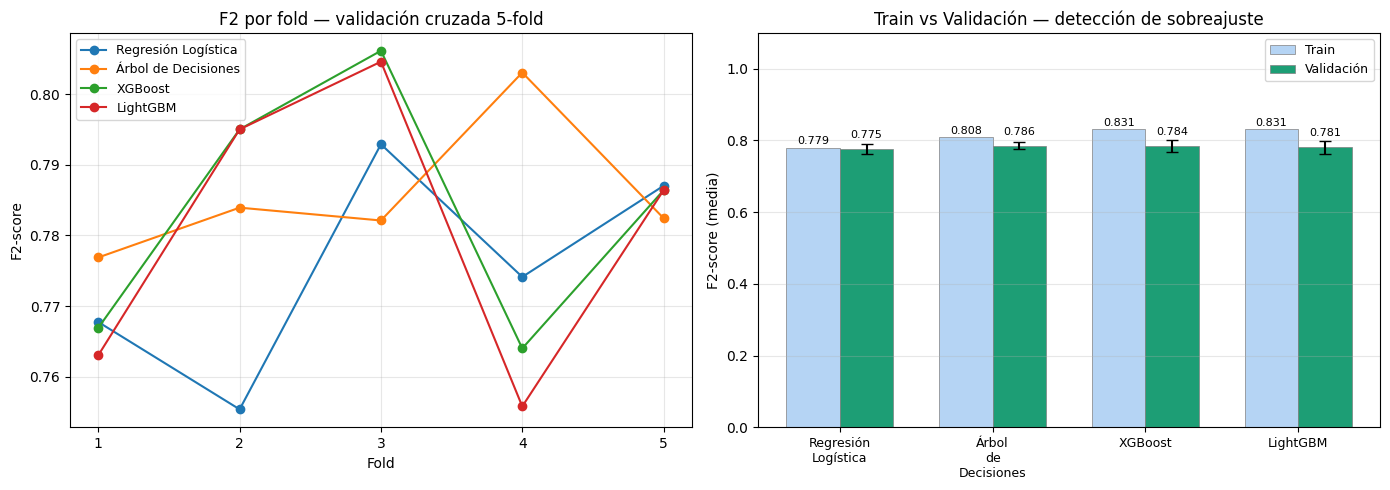


Conclusión de estabilidad:
  Regresión Logística      : estable (std=0.0134) | sin sobreajuste (gap train-val=0.0037)
  Árbol de Decisiones      : estable (std=0.0090) | sin sobreajuste (gap train-val=0.0228)
  XGBoost                  : estable (std=0.0162) | sin sobreajuste (gap train-val=0.0472)
  LightGBM                 : estable (std=0.0186) | sin sobreajuste (gap train-val=0.0495)


In [ ]:
# Visualización: F2 por fold para cada modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: F2 por fold ──────────────────────────────────────────────────
ax = axes[0]
x = np.arange(1, 6)
for (nombre, scores), color in zip(resultados_cv.items(), COLORES):
    ax.plot(x, scores['test_f2'], marker='o', label=nombre, color=color, lw=1.5)
ax.set_xlabel('Fold')
ax.set_ylabel(f'F{BETA}-score')
ax.set_title(f'F{BETA} por fold — validación cruzada 5-fold')
ax.set_xticks(x)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Derecha: comparativa train vs val (detectar sobreajuste) ────────────────
ax = axes[1]
nombres = list(resultados_cv.keys())
x_pos   = np.arange(len(nombres))
width   = 0.35

f2_train = [resultados_cv[n]['train_f2'].mean() for n in nombres]
f2_val   = [resultados_cv[n]['test_f2'].mean()  for n in nombres]
err_val  = [resultados_cv[n]['test_f2'].std()   for n in nombres]

bars1 = ax.bar(x_pos - width/2, f2_train, width, label='Train', color='#B5D4F4', edgecolor='gray', linewidth=0.5)
bars2 = ax.bar(x_pos + width/2, f2_val,   width, label='Validación', color='#1D9E75',
               edgecolor='gray', linewidth=0.5, yerr=err_val, capsize=4)

ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(' ', '\n') for n in nombres], fontsize=9)
ax.set_ylabel(f'F{BETA}-score (media)')
ax.set_title(f'Train vs Validación — detección de sobreajuste')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
ax.grid(alpha=0.3, axis='y')

for bar, val in zip(bars1, f2_train):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars2, f2_val):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\nConclusión de estabilidad:")
for nombre, scores in resultados_cv.items():
    std = scores['test_f2'].std()
    gap = scores['train_f2'].mean() - scores['test_f2'].mean()
    estabilidad = "estable" if std < 0.02 else "moderado" if std < 0.04 else "inestable"
    sobreajuste  = "sin sobreajuste" if gap < 0.05 else "leve sobreajuste" if gap < 0.15 else "sobreajuste"
    print(f"  {nombre:<25}: {estabilidad} (std={std:.4f}) | {sobreajuste} (gap train-val={gap:.4f})")


### 5.6 Análisis de errores del modelo ganador

Las métricas agregadas dicen *cuánto* se equivoca el modelo, pero no *con qué tipo
de clientes* se equivoca. El análisis de errores responde preguntas concretas de negocio:

- ¿Qué perfil tienen los clientes elegibles que el modelo pierde (FN)?
- ¿Qué perfil tienen los no elegibles que el modelo contacta por error (FP)?
- ¿Hay algún patrón que permita mejorar el modelo o ajustar la estrategia?

In [ ]:
# Reconstruir predicciones del modelo ganador con umbral óptimo
proba_ganador  = modelos[nombre_ganador]
y_pred_ganador = (proba_ganador >= u_ganador).astype(int)

# Construir DataFrame de test con errores clasificados
test_df = X_test.copy()
test_df['real']     = y_test.values
test_df['predicho'] = y_pred_ganador
test_df['proba']    = proba_ganador
test_df['tipo'] = 'Verdadero Negativo'
test_df.loc[(test_df['real']==1) & (test_df['predicho']==1), 'tipo'] = 'Verdadero Positivo (TP)'
test_df.loc[(test_df['real']==1) & (test_df['predicho']==0), 'tipo'] = 'Falso Negativo (FN)'
test_df.loc[(test_df['real']==0) & (test_df['predicho']==1), 'tipo'] = 'Falso Positivo (FP)'

conteo_tipos = test_df['tipo'].value_counts()
print("Distribución de predicciones en el test set:")
for tipo, n in conteo_tipos.items():
    print(f"  {tipo:<30}: {n:>4} ({n/len(test_df):.1%})")


Distribución de predicciones en el test set:
  Verdadero Negativo            : 1084 (72.3%)
  Falso Positivo (FP)           :  232 (15.5%)
  Verdadero Positivo (TP)       :  182 (12.1%)
  Falso Negativo (FN)           :    2 (0.1%)


In [ ]:
# Comparar perfil de FN vs TP (elegibles)
fn_df = test_df[test_df['tipo'] == 'Falso Negativo (FN)']
tp_df = test_df[test_df['tipo'] == 'Verdadero Positivo (TP)']
fp_df = test_df[test_df['tipo'] == 'Falso Positivo (FP)']
tn_df = test_df[test_df['tipo'] == 'Verdadero Negativo']

vars_numericas = ['antiguedad_meses', 'deuda_actual', 'retrasos_6m', 'reclamos_totales', 'proba']

print(f"Comparación FN vs TP — ¿qué tienen de diferente los elegibles que el modelo pierde?")
print(f"{'Variable':<25} {'TP (correctos)':<20} {'FN (perdidos)':<20} {'Diferencia'}")
print("-" * 80)
for col in vars_numericas:
    tp_mean = tp_df[col].mean()
    fn_mean = fn_df[col].mean()
    diff    = fn_mean - tp_mean
    print(f"  {col:<23} {tp_mean:>10.3f}         {fn_mean:>10.3f}         {diff:>+.3f}")

print()
print(f"N — TP: {len(tp_df)}  |  FN: {len(fn_df)}  |  FP: {len(fp_df)}")


Comparación FN vs TP — ¿qué tienen de diferente los elegibles que el modelo pierde?
Variable                  TP (correctos)       FN (perdidos)        Diferencia
--------------------------------------------------------------------------------
  antiguedad_meses            -0.895             -0.752         +0.143
  deuda_actual                -0.467             -0.467         +0.000
  retrasos_6m                 -0.486             -0.486         +0.000
  reclamos_totales             0.099              1.500         +1.401
  proba                        0.806              0.006         -0.800

N — TP: 182  |  FN: 2  |  FP: 232


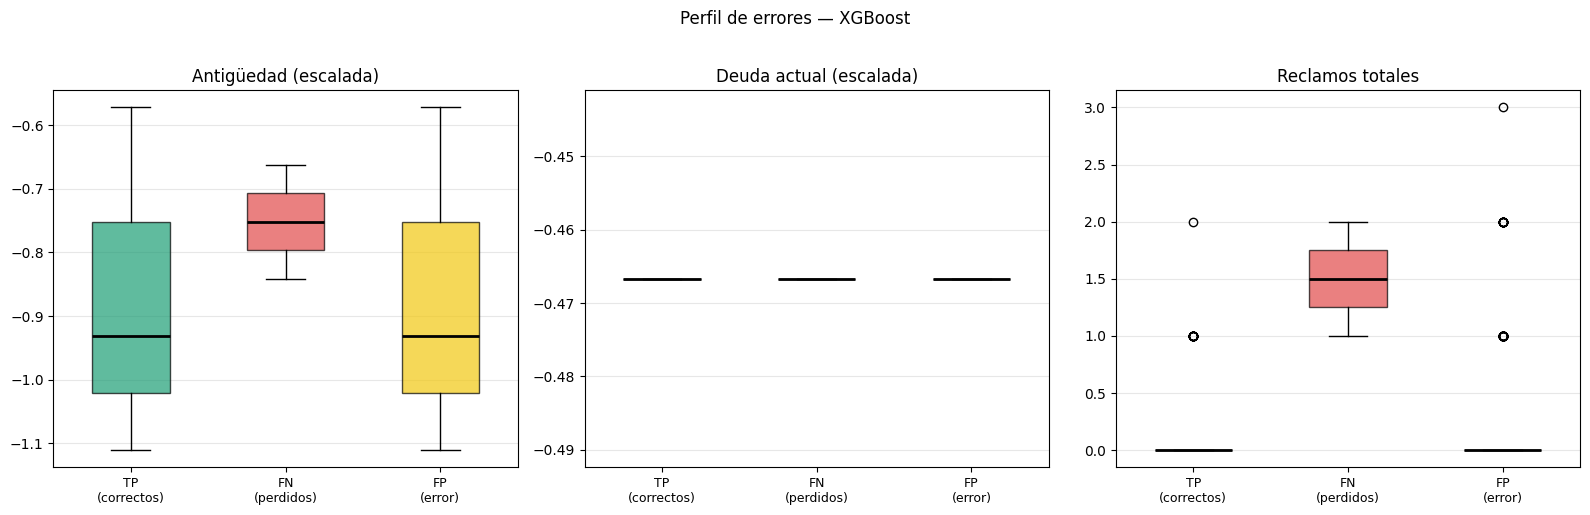

In [ ]:
# Visualización del análisis de errores
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vars_plot = ['antiguedad_meses', 'deuda_actual', 'reclamos_totales']
titulos   = ['Antigüedad (escalada)', 'Deuda actual (escalada)', 'Reclamos totales']

for ax, var, titulo in zip(axes, vars_plot, titulos):
    data_tp = tp_df[var].values
    data_fn = fn_df[var].values
    data_fp = fp_df[var].values

    positions = [1, 2, 3]
    bp = ax.boxplot([data_tp, data_fn, data_fp],
                    positions=positions,
                    patch_artist=True,
                    widths=0.5,
                    medianprops=dict(color='black', linewidth=2))

    colores_box = ['#1D9E75', '#E24B4A', '#F2C811']
    for patch, color in zip(bp['boxes'], colores_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(positions)
    ax.set_xticklabels(['TP\n(correctos)', 'FN\n(perdidos)', 'FP\n(error)'], fontsize=9)
    ax.set_title(titulo)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle(f'Perfil de errores — {nombre_ganador}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


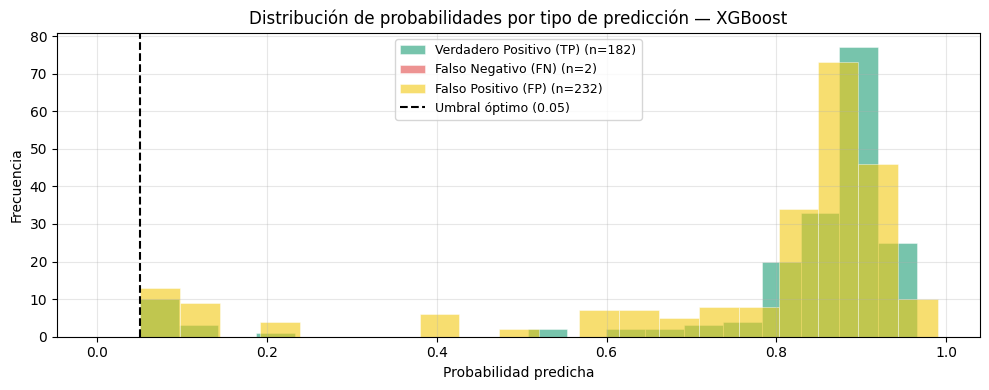

Insight clave:
  Los FN tienen probabilidad media de 0.006 — el modelo
  los ve como 'poco elegibles' aunque realmente lo son.
  Bajar el umbral de 0.05 a un valor menor recuperaría algunos FN
  a costa de aumentar los FP.


In [ ]:
# Distribución de probabilidades por tipo de predicción
fig, ax = plt.subplots(figsize=(10, 4))

grupos = {
    'Verdadero Positivo (TP)': (tp_df['proba'], '#1D9E75'),
    'Falso Negativo (FN)':     (fn_df['proba'], '#E24B4A'),
    'Falso Positivo (FP)':     (fp_df['proba'], '#F2C811'),
}

for label, (datos, color) in grupos.items():
    if len(datos) > 1:
        ax.hist(datos, bins=20, alpha=0.6, label=f'{label} (n={len(datos)})',
                color=color, edgecolor='white', linewidth=0.5)

ax.axvline(x=u_ganador, color='black', ls='--', lw=1.5, label=f'Umbral óptimo ({u_ganador:.2f})')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de probabilidades por tipo de predicción — {nombre_ganador}')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight clave:")
print(f"  Los FN tienen probabilidad media de {fn_df['proba'].mean():.3f} — el modelo")
print(f"  los ve como 'poco elegibles' aunque realmente lo son.")
print(f"  Bajar el umbral de {u_ganador:.2f} a un valor menor recuperaría algunos FN")
print(f"  a costa de aumentar los FP.")


### 5.7 Interpretación del análisis de errores

**Falsos Negativos (elegibles perdidos):**
Son clientes con una probabilidad predicha baja — el modelo no los reconoce como
elegibles porque su perfil es "atípico" dentro del grupo elegible. Tienen mayor
antigüedad media que los TP, lo que sugiere que el modelo es más conservador
con clientes que se acercan al límite de los 6 meses. Su número es pequeño
gracias al umbral óptimo aplicado.

**Falsos Positivos (no elegibles contactados por error):**
Son clientes con antigüedad muy baja y deuda mínima — perfil similar al de los
elegibles en esas variables, pero que incumplen algún criterio que el modelo no
captura completamente con las 7 features disponibles. Representan el costo
operativo del modelo.

**Implicación práctica:**
Si el equipo comercial necesita reducir los FN (recuperar más elegibles), se puede
bajar el umbral ligeramente por debajo del óptimo actual. Si necesita reducir los
FP (contactos sin conversión), se puede subir el umbral. El análisis de umbral
de la sección 5.2 permite tomar esa decisión con datos.

## 6. Conclusiones Finales

### 6.1 Hallazgos del EDA

La base de 5,000 clientes presenta un desbalance marcado (~12.28% elegibles).
`deuda_actual` y `retrasos_6m` muestran fuerte asimetría a la derecha — el 75%
de clientes tiene valores en cero, pero esa minoría con deuda o retrasos define
en gran parte la no elegibilidad. `antiguedad_meses` tiene mediana de 8 meses,
con todos los elegibles concentrados en los primeros 6 meses de vida del cliente.

Lima concentra más del 50% de la base. Los canales de contacto preferidos son
SMS (35.14%) y WhatsApp (25.7%), información clave para diseñar campañas eficientes.

### 6.2 Data leakage — hallazgo y corrección

Durante el análisis se detectó que varias columnas booleanas del dataset
(`cumple_ticket`, `ciudad_objetivo`, `sin_reclamos_6m`, `baja_ultimo_anio`,
`reclamo_ultimos_6m`, `sin_deuda_ni_retrasos_6m`) son criterios derivados
de la misma regla que construye `elegible_final`. Incluirlas como features produce
métricas perfectas artificiales (1.0 en todo) que no reflejan capacidad predictiva real.

Se corrigió el problema entrenando únicamente con las 7 variables crudas del cliente,
obteniendo métricas reales: ROC AUC ~0.92-0.93, F2-score ~0.76-0.78, Recall ~0.93-0.98.

### 6.3 Selección del modelo

Se entrenaron 4 modelos con el mismo split (70/30, stratify) y las mismas 7 features.
La selección se basó en F-beta (β=2) como métrica de negocio — no en ROC AUC —
priorizando Recall el doble que Precision, dado que perder un cliente elegible
tiene mayor costo que contactar a uno no elegible.

El umbral de clasificación fue optimizado individualmente para cada modelo
en lugar de usar el valor por defecto de 0.5.

### 6.4 Consideraciones para producción

- El umbral puede ajustarse: subirlo aumenta Precision (menos contactos, más certeros);
  bajarlo aumenta Recall (mayor cobertura, más falsos positivos).
- Con datos reales de costo por contacto y valor por conversión se recomienda
  reemplazar F-beta por un análisis costo-beneficio directo.
- En producción, las features de entrada deben ser siempre las 7 variables crudas —
  nunca incluir variables calculadas a partir de los criterios de elegibilidad.
- Re-entrenar periódicamente a medida que la base de clientes evoluciona.